In [2]:
%%writefile ../src/preprocessing.py

"""
Preprocessing utilities for the Explainable HPO
Imbalanced Tabular Classification project.
"""

import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline


def load_bank_marketing_data(
    data_path="../data/raw/bank-full.csv"
):
    """Load the UCI Bank Marketing dataset."""
    
    df = pd.read_csv(data_path)
    
    return df


def prepare_target(
    df,
    target_column="y"
):
    """Separate features and encode target: no=0, yes=1."""
    
    X = df.drop(columns=[target_column]).copy()
    
    y = df[target_column].map({
        "no": 0,
        "yes": 1
    })
    
    if y.isna().any():
        raise ValueError(
            "Target contains unexpected values. "
            "Expected 'no' and 'yes'."
        )
    
    return X, y.astype(int)


def identify_feature_types(X):
    """Identify numerical and categorical columns."""
    
    numeric_columns = X.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()
    
    categorical_columns = X.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
    
    return numeric_columns, categorical_columns


def build_preprocessor(
    numeric_columns,
    categorical_columns
):
    """Build leakage-safe preprocessing transformer."""
    
    numeric_pipeline = Pipeline(
        steps=[
            ("scaler", StandardScaler())
        ]
    )
    
    categorical_pipeline = Pipeline(
        steps=[
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )
    
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_columns
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_columns
            )
        ],
        remainder="drop"
    )
    
    return preprocessor


def prepare_preprocessing(
    df,
    target_column="y"
):
    """Prepare X, y and preprocessing transformer."""
    
    X, y = prepare_target(
        df,
        target_column
    )
    
    numeric_columns, categorical_columns = (
        identify_feature_types(X)
    )
    
    preprocessor = build_preprocessor(
        numeric_columns,
        categorical_columns
    )
    
    return (
        X,
        y,
        preprocessor,
        numeric_columns,
        categorical_columns
    )


def get_transformed_feature_names(
    fitted_preprocessor
):
    """Return transformed feature names."""
    
    return (
        fitted_preprocessor
        .get_feature_names_out()
        .tolist()
    )

Overwriting ../src/preprocessing.py


In [3]:
%%writefile ../src/models.py

"""
Model construction utilities.

Models used in the research:
- Logistic Regression
- Decision Tree
- Random Forest
"""

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


def build_logistic_regression(
    preprocessor,
    C=1.0,
    class_weight=None,
    random_state=42
):
    """Build Logistic Regression pipeline."""
    
    model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                LogisticRegression(
                    C=C,
                    class_weight=class_weight,
                    max_iter=1000,
                    random_state=random_state
                )
            )
        ]
    )
    
    return model


def build_decision_tree(
    preprocessor,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    criterion="gini",
    class_weight=None,
    random_state=42
):
    """Build Decision Tree pipeline."""
    
    model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                DecisionTreeClassifier(
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    criterion=criterion,
                    class_weight=class_weight,
                    random_state=random_state
                )
            )
        ]
    )
    
    return model


def build_random_forest(
    preprocessor,
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight=None,
    random_state=42
):
    """Build Random Forest pipeline."""
    
    model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    class_weight=class_weight,
                    random_state=random_state,
                    n_jobs=-1
                )
            )
        ]
    )
    
    return model


def get_default_models(
    preprocessor,
    random_state=42
):
    """Return the three default research models."""
    
    return {
        "Logistic Regression":
            build_logistic_regression(
                preprocessor,
                random_state=random_state
            ),
        
        "Decision Tree":
            build_decision_tree(
                preprocessor,
                random_state=random_state
            ),
        
        "Random Forest":
            build_random_forest(
                preprocessor,
                random_state=random_state
            )
    }

Overwriting ../src/models.py


In [4]:
%%writefile ../src/imbalance.py

"""
Imbalance-handling utilities.

Strategies:
1. Original imbalanced data
2. Class weighting
3. SMOTENC
"""

import numpy as np

from imblearn.over_sampling import SMOTENC


def calculate_class_distribution(y):
    """Return class counts and percentages."""
    
    counts = y.value_counts().sort_index()
    
    percentages = (
        counts / len(y) * 100
    )
    
    return counts, percentages


def calculate_imbalance_ratio(y):
    """Calculate majority/minority class ratio."""
    
    counts = y.value_counts()
    
    if len(counts) != 2:
        raise ValueError(
            "This function requires a binary target."
        )
    
    return (
        counts.max() /
        counts.min()
    )


def get_class_weights(y):
    """
    Calculate balanced class weights.
    
    Returns:
        Dictionary suitable for sklearn class_weight.
    """
    
    counts = y.value_counts()
    
    total = len(y)
    n_classes = len(counts)
    
    weights = {}
    
    for class_value, count in counts.items():
        weights[class_value] = (
            total /
            (n_classes * count)
        )
    
    return weights


def apply_smotenc(
    X_train,
    y_train,
    categorical_columns,
    random_state=42
):
    """
    Apply SMOTENC to training data only.
    
    Important:
    SMOTENC must never be applied to the
    untouched test set.
    """
    
    categorical_indices = [
        X_train.columns.get_loc(column)
        for column in categorical_columns
    ]
    
    smotenc = SMOTENC(
        categorical_features=categorical_indices,
        random_state=random_state
    )
    
    X_resampled, y_resampled = (
        smotenc.fit_resample(
            X_train,
            y_train
        )
    )
    
    return (
        X_resampled,
        y_resampled,
        smotenc
    )


def get_resampled_distribution(y):
    """Return distribution after resampling."""
    
    counts = y.value_counts().sort_index()
    
    percentages = (
        counts / len(y) * 100
    )
    
    return counts, percentages

Overwriting ../src/imbalance.py


In [5]:
%%writefile ../src/hpo.py

"""
Hyperparameter Optimization utilities.

Framework:
Optuna + Stratified K-Fold Cross Validation

Primary optimization metric:
F1 Score

Models:
- Logistic Regression
- Decision Tree
- Random Forest
"""

import optuna
import numpy as np

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


def create_cv(
    n_splits=3,
    random_state=42
):
    """Create stratified cross-validation."""
    
    return StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )


def optimize_logistic_regression(
    X,
    y,
    preprocessor,
    n_trials=20,
    random_state=42,
    scoring="f1"
):
    """Optimize Logistic Regression using Optuna."""
    
    cv = create_cv(
        n_splits=3,
        random_state=random_state
    )
    
    def objective(trial):
        
        C = trial.suggest_float(
            "C",
            1e-3,
            10,
            log=True
        )
        
        class_weight = trial.suggest_categorical(
            "class_weight",
            [None, "balanced"]
        )
        
        model = Pipeline(
            steps=[
                (
                    "preprocessor",
                    preprocessor
                ),
                (
                    "classifier",
                    LogisticRegression(
                        C=C,
                        class_weight=class_weight,
                        max_iter=1000,
                        random_state=random_state
                    )
                )
            ]
        )
        
        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )
        
        return scores.mean()
    
    study = optuna.create_study(
        direction="maximize"
    )
    
    study.optimize(
        objective,
        n_trials=n_trials
    )
    
    return study


def optimize_decision_tree(
    X,
    y,
    preprocessor,
    n_trials=20,
    random_state=42,
    scoring="f1"
):
    """Optimize Decision Tree using Optuna."""
    
    cv = create_cv(
        n_splits=3,
        random_state=random_state
    )
    
    def objective(trial):
        
        max_depth = trial.suggest_int(
            "max_depth",
            3,
            30
        )
        
        min_samples_split = trial.suggest_int(
            "min_samples_split",
            2,
            20
        )
        
        min_samples_leaf = trial.suggest_int(
            "min_samples_leaf",
            1,
            10
        )
        
        max_features = trial.suggest_categorical(
            "max_features",
            [None, "sqrt", "log2"]
        )
        
        criterion = trial.suggest_categorical(
            "criterion",
            ["gini", "entropy", "log_loss"]
        )
        
        class_weight = trial.suggest_categorical(
            "class_weight",
            [None, "balanced"]
        )
        
        model = Pipeline(
            steps=[
                (
                    "preprocessor",
                    preprocessor
                ),
                (
                    "classifier",
                    DecisionTreeClassifier(
                        max_depth=max_depth,
                        min_samples_split=min_samples_split,
                        min_samples_leaf=min_samples_leaf,
                        max_features=max_features,
                        criterion=criterion,
                        class_weight=class_weight,
                        random_state=random_state
                    )
                )
            ]
        )
        
        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )
        
        return scores.mean()
    
    study = optuna.create_study(
        direction="maximize"
    )
    
    study.optimize(
        objective,
        n_trials=n_trials
    )
    
    return study


def optimize_random_forest(
    X,
    y,
    preprocessor,
    n_trials=20,
    random_state=42,
    scoring="f1"
):
    """Optimize Random Forest using Optuna."""
    
    cv = create_cv(
        n_splits=3,
        random_state=random_state
    )
    
    def objective(trial):
        
        n_estimators = trial.suggest_int(
            "n_estimators",
            100,
            500,
            step=50
        )
        
        max_depth = trial.suggest_int(
            "max_depth",
            5,
            30
        )
        
        min_samples_split = trial.suggest_int(
            "min_samples_split",
            2,
            20
        )
        
        min_samples_leaf = trial.suggest_int(
            "min_samples_leaf",
            1,
            10
        )
        
        max_features = trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        )
        
        class_weight = trial.suggest_categorical(
            "class_weight",
            [None, "balanced"]
        )
        
        model = Pipeline(
            steps=[
                (
                    "preprocessor",
                    preprocessor
                ),
                (
                    "classifier",
                    RandomForestClassifier(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        min_samples_split=min_samples_split,
                        min_samples_leaf=min_samples_leaf,
                        max_features=max_features,
                        class_weight=class_weight,
                        random_state=random_state,
                        n_jobs=-1
                    )
                )
            ]
        )
        
        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=1
        )
        
        return scores.mean()
    
    study = optuna.create_study(
        direction="maximize"
    )
    
    study.optimize(
        objective,
        n_trials=n_trials
    )
    
    return study


def get_best_parameters(study):
    """Return best parameters from an Optuna study."""
    
    return study.best_params


def get_best_score(study):
    """Return best objective score."""
    
    return study.best_value

Overwriting ../src/hpo.py


In [6]:
%%writefile ../src/evaluation.py

"""
Model evaluation utilities for binary imbalanced classification.
"""

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix
)


def calculate_metrics(
    y_true,
    y_prediction,
    y_probability=None
):
    """
    Calculate classification metrics.
    """
    
    results = {
        "Accuracy": accuracy_score(
            y_true,
            y_prediction
        ),
        
        "Precision": precision_score(
            y_true,
            y_prediction,
            zero_division=0
        ),
        
        "Recall": recall_score(
            y_true,
            y_prediction,
            zero_division=0
        ),
        
        "F1": f1_score(
            y_true,
            y_prediction,
            zero_division=0
        ),
        
        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_prediction
            )
    }
    
    if y_probability is not None:
        
        results["ROC_AUC"] = (
            roc_auc_score(
                y_true,
                y_probability
            )
        )
        
        results["PR_AUC"] = (
            average_precision_score(
                y_true,
                y_probability
            )
        )
    
    return results


def calculate_threshold_metrics(
    y_true,
    y_probability,
    threshold
):
    """Calculate metrics at a specific threshold."""
    
    y_prediction = (
        y_probability >= threshold
    ).astype(int)
    
    metrics = calculate_metrics(
        y_true,
        y_prediction,
        y_probability
    )
    
    metrics["Threshold"] = threshold
    
    return metrics


def evaluate_threshold_range(
    y_true,
    y_probability,
    thresholds=None
):
    """Evaluate a range of classification thresholds."""
    
    if thresholds is None:
        thresholds = np.round(
            np.arange(
                0.10,
                0.91,
                0.01
            ),
            2
        )
    
    results = []
    
    for threshold in thresholds:
        
        metrics = calculate_threshold_metrics(
            y_true,
            y_probability,
            threshold
        )
        
        results.append(metrics)
    
    return pd.DataFrame(results)


def get_confusion_matrix(
    y_true,
    y_prediction
):
    """Return confusion matrix."""
    
    return confusion_matrix(
        y_true,
        y_prediction
    )


def compare_thresholds(
    y_true,
    y_probability,
    default_threshold=0.50,
    optimized_threshold=0.22
):
    """Compare default and optimized thresholds."""
    
    default_metrics = calculate_threshold_metrics(
        y_true,
        y_probability,
        default_threshold
    )
    
    optimized_metrics = calculate_threshold_metrics(
        y_true,
        y_probability,
        optimized_threshold
    )
    
    default_metrics["Threshold_Type"] = (
        "Default 0.50"
    )
    
    optimized_metrics["Threshold_Type"] = (
        "F1 Optimized"
    )
    
    return pd.DataFrame([
        default_metrics,
        optimized_metrics
    ])

Overwriting ../src/evaluation.py


In [7]:
%%writefile ../src/explainability.py

"""
Explainable AI utilities using SHAP.

Primary model:
Logistic Regression

Purpose:
- Global feature importance
- Local prediction explanations
- Explanation stability analysis
"""

import numpy as np
import pandas as pd
import shap


def get_transformed_feature_names(
    fitted_pipeline
):
    """Extract transformed feature names from pipeline."""
    
    preprocessor = (
        fitted_pipeline
        .named_steps["preprocessor"]
    )
    
    return (
        preprocessor
        .get_feature_names_out()
        .tolist()
    )


def get_classifier(
    fitted_pipeline
):
    """Extract classifier from fitted pipeline."""
    
    return fitted_pipeline.named_steps[
        "classifier"
    ]


def get_transformed_data(
    fitted_pipeline,
    X
):
    """Transform raw data using fitted preprocessing."""
    
    preprocessor = (
        fitted_pipeline
        .named_steps["preprocessor"]
    )
    
    return preprocessor.transform(X)


def create_logistic_shap_explainer(
    fitted_pipeline,
    X_background
):
    """
    Create SHAP LinearExplainer for
    Logistic Regression.
    """
    
    transformed_background = (
        get_transformed_data(
            fitted_pipeline,
            X_background
        )
    )
    
    classifier = get_classifier(
        fitted_pipeline
    )
    
    explainer = shap.LinearExplainer(
        classifier,
        transformed_background
    )
    
    return explainer


def calculate_shap_values(
    fitted_pipeline,
    X_background,
    X_explain
):
    """
    Calculate SHAP values for Logistic Regression.
    """
    
    explainer = create_logistic_shap_explainer(
        fitted_pipeline,
        X_background
    )
    
    transformed_data = (
        get_transformed_data(
            fitted_pipeline,
            X_explain
        )
    )
    
    shap_values = explainer(
        transformed_data
    )
    
    return shap_values


def calculate_global_shap_importance(
    shap_values,
    feature_names
):
    """
    Calculate mean absolute SHAP importance.
    """
    
    values = shap_values.values
    
    if values.ndim == 3:
        values = values[:, :, 1]
    
    importance = np.abs(values).mean(
        axis=0
    )
    
    result = pd.DataFrame({
        "Feature": feature_names,
        "Mean_Absolute_SHAP": importance
    })
    
    result = (
        result
        .sort_values(
            "Mean_Absolute_SHAP",
            ascending=False
        )
        .reset_index(drop=True)
    )
    
    return result


def create_local_explanation(
    shap_values,
    feature_names,
    sample_index=0
):
    """Create a local SHAP explanation table."""
    
    values = shap_values.values
    
    if values.ndim == 3:
        values = values[:, :, 1]
    
    row = values[sample_index]
    
    explanation = pd.DataFrame({
        "Feature": feature_names,
        "SHAP_Value": row,
        "Absolute_SHAP": np.abs(row)
    })
    
    explanation = (
        explanation
        .sort_values(
            "Absolute_SHAP",
            ascending=False
        )
        .reset_index(drop=True)
    )
    
    return explanation


def calculate_top_feature_overlap(
    importance_tables,
    top_n=10
):
    """
    Calculate Jaccard overlap of top-N
    SHAP features across experiments.
    """
    
    feature_sets = []
    
    for table in importance_tables:
        
        top_features = set(
            table
            .head(top_n)["Feature"]
            .tolist()
        )
        
        feature_sets.append(
            top_features
        )
    
    overlaps = []
    
    for i in range(
        len(feature_sets)
    ):
        
        for j in range(
            i + 1,
            len(feature_sets)
        ):
            
            intersection = (
                feature_sets[i]
                .intersection(
                    feature_sets[j]
                )
            )
            
            union = (
                feature_sets[i]
                .union(
                    feature_sets[j]
                )
            )
            
            jaccard = (
                len(intersection) /
                len(union)
                if union
                else 0
            )
            
            overlaps.append({
                "Experiment_A": i,
                "Experiment_B": j,
                "Jaccard": jaccard
            })
    
    return pd.DataFrame(overlaps)

Overwriting ../src/explainability.py


In [8]:
%%writefile ../README.md

# Explainable Hyperparameter Optimization for Imbalanced Tabular Classification

## Project Overview

This project investigates an explainable and imbalance-aware hyperparameter optimization framework for binary tabular classification.

The current case study uses the UCI Bank Marketing dataset to predict whether a customer subscribes to a term deposit.

The research combines:

- Imbalanced classification
- Hyperparameter optimization
- Multi-objective optimization
- Threshold optimization
- Robustness analysis
- Explainable AI
- SHAP explanation stability

The goal is not only to obtain a predictive model, but to study how optimization objectives, class imbalance handling, decision thresholds, model robustness, and explanations interact.

---

## Research Problem

Binary tabular classification datasets frequently contain class imbalance.

For the Bank Marketing dataset, the positive subscription class is substantially smaller than the negative class.

Therefore, accuracy alone can provide a misleading assessment of model performance.

This project evaluates models using metrics such as:

- Precision
- Recall
- F1 Score
- PR-AUC
- ROC-AUC
- Balanced Accuracy

The project additionally investigates whether hyperparameter optimization and threshold selection can improve minority-class performance while maintaining robust and interpretable predictions.

---

## Dataset

Dataset:

UCI Bank Marketing Dataset

File used:

`bank-full.csv`

Target variable:

`y`

Target encoding:

- `no` = 0
- `yes` = 1

Dataset size:

45,211 observations

Number of variables:

17

The raw dataset is not required to be committed to the repository.

---

## Research Questions

### RQ1

Does imbalance-aware learning improve minority-class classification performance?

### RQ2

Can hyperparameter optimization improve performance compared with default model configurations?

### RQ3

How do different optimization objectives affect model performance?

### RQ4

How does classification threshold optimization change the precision-recall trade-off?

### RQ5

How robust are the model results across different random seeds?

### RQ6

How stable are SHAP-based explanations across repeated experiments?

---

## Models

The experimental study evaluates:

1. Logistic Regression
2. Decision Tree
3. Random Forest

---

## Imbalance Strategies

The project investigates:

1. Original imbalanced training data
2. Class weighting
3. SMOTENC

SMOTENC is applied only to training data to prevent data leakage.

---

## Hyperparameter Optimization

Optuna is used for hyperparameter optimization.

The primary single-objective optimization metric is F1 Score.

The study uses stratified cross-validation.

The actual Stage 6 trial counts were:

- Logistic Regression: 20 trials
- Decision Tree: 20 trials
- Random Forest: 40 completed trials

The Random Forest study was continued beyond the initially planned budget, and the actual number of completed trials is reported for reproducibility.

---

## Multi-objective Optimization

A separate experimental stage evaluates simultaneous optimization of:

- F1 Score
- PR-AUC

The resulting Pareto solutions are analyzed rather than assuming that one metric is universally optimal.

---

## Threshold Optimization

Classification threshold selection is investigated using out-of-fold training probabilities.

The default threshold is:

`0.50`

The F1-oriented threshold search evaluates:

`0.10` through `0.90`

in increments of `0.01`.

The selected threshold is determined using training OOF predictions and is subsequently evaluated on the untouched test set.

---

## Robustness

Robustness is evaluated using repeated stratified experiments across multiple random seeds.

The results are summarized using mean and standard deviation where applicable.

---

## Explainable AI

SHAP is used to investigate:

### Global explanations

Mean absolute SHAP importance is used to identify influential transformed features.

### Local explanations

Individual predictions are analyzed through their SHAP contributions.

### Explanation stability

Repeated experiments are compared using feature-overlap and ranking-based stability measures.

SHAP explanations represent model behavior and should not automatically be interpreted as causal relationships.

---

## Project Structure

```text
HPO_Explainable_Marketing/
│
├── data/
│   └── raw/
│       └── bank-full.csv
│
├── notebooks/
│   ├── 01_data_understanding.ipynb
│   ├── 02_eda_imbalance.ipynb
│   ├── 03_preprocessing.ipynb
│   ├── 04_baseline_models.ipynb
│   ├── 05_imbalance_strategies.ipynb
│   ├── 06_hpo_experiments.ipynb
│   ├── 07_multiobjective_hpo.ipynb
│   ├── 08_threshold_optimization.ipynb
│   ├── 09_robustness_analysis.ipynb
│   ├── 10_xai_shap.ipynb
│   ├── 11_explanation_stability.ipynb
│   └── 12_final_results.ipynb
│
├── src/
│   ├── preprocessing.py
│   ├── models.py
│   ├── imbalance.py
│   ├── hpo.py
│   ├── evaluation.py
│   └── explainability.py
│
├── results/
│   ├── metrics/
│   ├── hpo/
│   ├── plots/
│   └── shap/
│
├── references/
│
├── requirements.txt
└── README.md

Overwriting ../README.md


In [9]:
# ================================================================
# MASTER PLOT GENERATOR
# Explainable HPO for Imbalanced Tabular Marketing Classification
# Dataset: UCI Bank Marketing - bank-full.csv
#
# This cell:
# 1. Reads existing experimental results
# 2. Generates research/paper-ready Plotly figures
# 3. Saves HTML files to ../results/plots/
# 4. Optionally saves PNG files if Kaleido is installed
# 5. Does NOT rerun any ML experiments
# ================================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path


# ================================================================
# 1. PATH SETUP
# ================================================================

PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"

METRICS_DIR = RESULTS_DIR / "metrics"
HPO_DIR = RESULTS_DIR / "hpo"
SHAP_DIR = RESULTS_DIR / "shap"
PLOTS_DIR = RESULTS_DIR / "plots"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "bank-full.csv"


# ================================================================
# 2. PLOT SAVE FUNCTION
# ================================================================

PLOT_COUNT = 0


def save_plot(fig, filename, title=None):
    """
    Save Plotly figure as HTML.
    Also attempts PNG export if Kaleido is installed.
    """

    global PLOT_COUNT

    if title is not None:
        fig.update_layout(title=title)

    fig.update_layout(
        template="plotly_white",
        font=dict(size=12),
        margin=dict(l=70, r=40, t=80, b=100)
    )

    html_path = PLOTS_DIR / f"{filename}.html"

    fig.write_html(
        str(html_path),
        include_plotlyjs="cdn"
    )

    # Try PNG export
    try:
        png_path = PLOTS_DIR / f"{filename}.png"
        fig.write_image(
            str(png_path),
            scale=2
        )
        png_status = " + PNG"
    except Exception:
        png_status = " + HTML only"

    PLOT_COUNT += 1

    print(f"✓ {filename}{png_status}")


def safe_read_csv(path):
    """Read CSV if it exists."""
    if path.exists():
        try:
            df = pd.read_csv(path)
            print(f"✓ Loaded: {path}")
            return df
        except Exception as e:
            print(f"⚠ Could not read {path}: {e}")
            return None

    print(f"⚠ Missing: {path}")
    return None


# ================================================================
# 3. LOAD DATA
# ================================================================

print("=" * 90)
print("MASTER PLOT GENERATION")
print("=" * 90)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully.")
print("Shape:", df.shape)


# ================================================================
# 4. LOAD ALL EXISTING RESULTS
# ================================================================

baseline_results = safe_read_csv(
    METRICS_DIR / "baseline_results.csv"
)

imbalance_results = safe_read_csv(
    METRICS_DIR / "imbalance_strategy_results.csv"
)

imbalance_summary = safe_read_csv(
    METRICS_DIR / "imbalance_strategy_summary.csv"
)

hpo_results = safe_read_csv(
    METRICS_DIR / "hpo_results.csv"
)

multiobjective_results = safe_read_csv(
    METRICS_DIR / "multiobjective_pareto_results.csv"
)

threshold_results = safe_read_csv(
    METRICS_DIR / "threshold_results.csv"
)

threshold_comparison = safe_read_csv(
    METRICS_DIR / "threshold_test_comparison.csv"
)

robustness_results = safe_read_csv(
    METRICS_DIR / "robustness_summary.csv"
)

xai_model_metrics = safe_read_csv(
    METRICS_DIR / "xai_model_metrics.csv"
)

final_model_comparison = safe_read_csv(
    METRICS_DIR / "final_model_comparison.csv"
)

final_stage_summary = safe_read_csv(
    METRICS_DIR / "final_stage_summary.csv"
)

paper_model_metrics = safe_read_csv(
    METRICS_DIR / "paper_model_metrics.csv"
)

global_shap = safe_read_csv(
    SHAP_DIR / "global_shap_importance.csv"
)

local_shap = safe_read_csv(
    SHAP_DIR / "local_shap_explanation.csv"
)

shap_stability = safe_read_csv(
    SHAP_DIR / "shap_stability_summary.csv"
)

shap_feature_stability = safe_read_csv(
    SHAP_DIR / "shap_stability_feature_summary.csv"
)

shap_top10_overlap = safe_read_csv(
    SHAP_DIR / "shap_top10_overlap.csv"
)

shap_spearman = safe_read_csv(
    SHAP_DIR / "shap_spearman_stability.csv"
)

shap_top10_frequency = safe_read_csv(
    SHAP_DIR / "shap_top10_frequency.csv"
)

logistic_trials = safe_read_csv(
    HPO_DIR / "logistic_trials.csv"
)

decision_tree_trials = safe_read_csv(
    HPO_DIR / "decision_tree_trials.csv"
)

random_forest_trials = safe_read_csv(
    HPO_DIR / "random_forest_trials.csv"
)

logistic_multi_trials = safe_read_csv(
    HPO_DIR / "logistic_multiobjective_trials.csv"
)

tree_multi_trials = safe_read_csv(
    HPO_DIR / "decision_tree_multiobjective_trials.csv"
)

rf_multi_trials = safe_read_csv(
    HPO_DIR / "random_forest_multiobjective_trials.csv"
)


# ================================================================
# STAGE 1
# DATA UNDERSTANDING
# ================================================================

print("\n" + "=" * 90)
print("STAGE 1 — DATA UNDERSTANDING")
print("=" * 90)


# ------------------------------------------------
# 1. Target distribution
# ------------------------------------------------

if "y" in df.columns:

    target_counts = (
        df["y"]
        .value_counts()
        .rename_axis("Target")
        .reset_index(name="Count")
    )

    fig = px.bar(
        target_counts,
        x="Target",
        y="Count",
        text="Count",
        title="Target Class Distribution",
        labels={
            "Target": "Subscription",
            "Count": "Number of Customers"
        }
    )

    fig.update_traces(
        textposition="outside"
    )

    save_plot(
        fig,
        "01_target_class_distribution"
    )


# ------------------------------------------------
# 2. Numerical feature distributions
# ------------------------------------------------

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

for column in numeric_columns:

    fig = px.histogram(
        df,
        x=column,
        nbins=40,
        marginal="box",
        title=f"Distribution of {column}",
        labels={
            column: column
        }
    )

    save_plot(
        fig,
        f"01_distribution_{column}"
    )


# ================================================================
# STAGE 2
# EDA + IMBALANCE
# ================================================================

print("\n" + "=" * 90)
print("STAGE 2 — EDA + IMBALANCE")
print("=" * 90)


# ------------------------------------------------
# 3. Target percentage
# ------------------------------------------------

if "y" in df.columns:

    target_percentage = (
        df["y"]
        .value_counts(normalize=True)
        .mul(100)
        .rename_axis("Target")
        .reset_index(name="Percentage")
    )

    fig = px.pie(
        target_percentage,
        names="Target",
        values="Percentage",
        title="Target Class Proportion"
    )

    save_plot(
        fig,
        "02_target_class_proportion"
    )


# ------------------------------------------------
# 4. Numerical feature vs target
# ------------------------------------------------

if "y" in df.columns:

    for column in numeric_columns:

        fig = px.box(
            df,
            x="y",
            y=column,
            points=False,
            title=f"{column} by Subscription Outcome",
            labels={
                "y": "Subscription",
                column: column
            }
        )

        save_plot(
            fig,
            f"02_{column}_by_target"
        )


# ------------------------------------------------
# 5. Categorical subscription rates
# ------------------------------------------------

categorical_columns = df.select_dtypes(
    exclude=np.number
).columns.tolist()

if "y" in categorical_columns:
    categorical_columns.remove("y")

for column in categorical_columns:

    if df[column].nunique() <= 15:

        rate_df = (
            df.groupby(column)["y"]
            .apply(lambda x: (x == "yes").mean() * 100)
            .reset_index(name="Subscription_Rate")
            .sort_values(
                "Subscription_Rate",
                ascending=False
            )
        )

        fig = px.bar(
            rate_df,
            x=column,
            y="Subscription_Rate",
            text=rate_df["Subscription_Rate"].round(2),
            title=f"Subscription Rate by {column}",
            labels={
                "Subscription_Rate":
                    "Subscription Rate (%)"
            }
        )

        fig.update_traces(
            textposition="outside"
        )

        fig.update_layout(
            xaxis_tickangle=-45
        )

        save_plot(
            fig,
            f"02_subscription_rate_{column}"
        )


# ------------------------------------------------
# 6. Correlation heatmap
# ------------------------------------------------

if len(numeric_columns) >= 2:

    correlation = df[numeric_columns].corr()

    fig = px.imshow(
        correlation,
        text_auto=".2f",
        aspect="auto",
        title="Numerical Feature Correlation Matrix"
    )

    save_plot(
        fig,
        "02_numeric_correlation_heatmap"
    )


# ================================================================
# STAGE 3
# PREPROCESSING
# ================================================================

print("\n" + "=" * 90)
print("STAGE 3 — PREPROCESSING")
print("=" * 90)


# ------------------------------------------------
# 7. Train/test class distribution
# ------------------------------------------------

try:

    from sklearn.model_selection import train_test_split

    X_temp = df.drop(columns=["y"])
    y_temp = df["y"].map({
        "no": 0,
        "yes": 1
    })

    _, _, y_train_temp, y_test_temp = train_test_split(
        X_temp,
        y_temp,
        test_size=0.20,
        random_state=42,
        stratify=y_temp
    )

    split_df = pd.DataFrame({
        "Dataset": (
            ["Train"] * len(y_train_temp)
            + ["Test"] * len(y_test_temp)
        ),
        "Target": (
            list(y_train_temp)
            + list(y_test_temp)
        )
    })

    split_df["Target"] = split_df["Target"].map({
        0: "no",
        1: "yes"
    })

    split_counts = (
        split_df
        .groupby(["Dataset", "Target"])
        .size()
        .reset_index(name="Count")
    )

    fig = px.bar(
        split_counts,
        x="Dataset",
        y="Count",
        color="Target",
        barmode="group",
        title="Train/Test Target Distribution"
    )

    save_plot(
        fig,
        "03_train_test_target_distribution"
    )

except Exception as e:

    print(
        "⚠ Stage 3 plot skipped:",
        e
    )


# ================================================================
# STAGE 4
# BASELINE MODELS
# ================================================================

print("\n" + "=" * 90)
print("STAGE 4 — BASELINE MODELS")
print("=" * 90)


if baseline_results is not None:

    # ------------------------------------------------
    # 8. Baseline F1
    # ------------------------------------------------

    f1_col = None

    for candidate in [
        "F1",
        "F1_Score"
    ]:

        if candidate in baseline_results.columns:
            f1_col = candidate
            break

    if f1_col:

        plot_df = baseline_results.copy()

        fig = px.bar(
            plot_df,
            x="Model",
            y=f1_col,
            text=plot_df[f1_col].round(4),
            title="Baseline Model F1 Score"
        )

        fig.update_traces(
            textposition="outside"
        )

        save_plot(
            fig,
            "04_baseline_f1"
        )


    # ------------------------------------------------
    # 9. Baseline metrics
    # ------------------------------------------------

    metric_candidates = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "F1_Score",
        "Balanced_Accuracy",
        "ROC_AUC",
        "PR_AUC"
    ]

    available_metrics = [
        c for c in metric_candidates
        if c in baseline_results.columns
    ]

    if available_metrics:

        id_columns = [
            c for c in ["Model"]
            if c in baseline_results.columns
        ]

        melted = baseline_results.melt(
            id_vars=id_columns,
            value_vars=available_metrics,
            var_name="Metric",
            value_name="Score"
        )

        fig = px.bar(
            melted,
            x="Metric",
            y="Score",
            color="Model",
            barmode="group",
            title="Baseline Model Performance Comparison"
        )

        save_plot(
            fig,
            "04_baseline_model_metrics"
        )


# ================================================================
# STAGE 5
# IMBALANCE STRATEGIES
# ================================================================

print("\n" + "=" * 90)
print("STAGE 5 — IMBALANCE STRATEGIES")
print("=" * 90)


if imbalance_results is not None:

    # ------------------------------------------------
    # 10. Imbalance strategy F1
    # ------------------------------------------------

    f1_col = next(
        (
            c for c in
            ["F1", "F1_Score"]
            if c in imbalance_results.columns
        ),
        None
    )

    if f1_col:

        fig = px.bar(
            imbalance_results,
            x="Model",
            y=f1_col,
            color=(
                "Strategy"
                if "Strategy" in imbalance_results.columns
                else None
            ),
            barmode="group",
            title="F1 Score Across Imbalance Strategies"
        )

        save_plot(
            fig,
            "05_imbalance_strategy_f1"
        )


    # ------------------------------------------------
    # 11. Recall comparison
    # ------------------------------------------------

    if "Recall" in imbalance_results.columns:

        fig = px.bar(
            imbalance_results,
            x="Model",
            y="Recall",
            color=(
                "Strategy"
                if "Strategy" in imbalance_results.columns
                else None
            ),
            barmode="group",
            title="Recall Across Imbalance Strategies"
        )

        save_plot(
            fig,
            "05_imbalance_strategy_recall"
        )


# ================================================================
# STAGE 6
# HYPERPARAMETER OPTIMIZATION
# ================================================================

print("\n" + "=" * 90)
print("STAGE 6 — HYPERPARAMETER OPTIMIZATION")
print("=" * 90)


trial_files = {
    "Logistic Regression":
        logistic_trials,
    "Decision Tree":
        decision_tree_trials,
    "Random Forest":
        random_forest_trials
}


for model_name, trials in trial_files.items():

    if trials is None:
        continue

    # ------------------------------------------------
    # 12. Optimization history
    # ------------------------------------------------

    if "value" in trials.columns:

        history = trials.copy()

        history["Trial"] = np.arange(
            len(history)
        )

        history["Best_F1"] = (
            history["value"]
            .cummax()
        )

        fig = go.Figure()

        fig.add_trace(
            go.Scatter(
                x=history["Trial"],
                y=history["value"],
                mode="lines+markers",
                name="Trial F1"
            )
        )

        fig.add_trace(
            go.Scatter(
                x=history["Trial"],
                y=history["Best_F1"],
                mode="lines",
                name="Best F1 So Far"
            )
        )

        fig.update_layout(
            title=f"HPO Optimization History — {model_name}",
            xaxis_title="Trial",
            yaxis_title="F1 Score"
        )

        safe_name = (
            model_name
            .lower()
            .replace(" ", "_")
        )

        save_plot(
            fig,
            f"06_hpo_history_{safe_name}"
        )


# ------------------------------------------------
# 13. HPO result comparison
# ------------------------------------------------

if hpo_results is not None:

    f1_col = next(
        (
            c for c in
            ["F1", "F1_Score"]
            if c in hpo_results.columns
        ),
        None
    )

    if f1_col and "Model" in hpo_results.columns:

        fig = px.bar(
            hpo_results,
            x="Model",
            y=f1_col,
            text=hpo_results[f1_col].round(4),
            title="HPO Model Performance"
        )

        fig.update_traces(
            textposition="outside"
        )

        save_plot(
            fig,
            "06_hpo_model_comparison"
        )


# ================================================================
# STAGE 7
# MULTI-OBJECTIVE HPO
# ================================================================

print("\n" + "=" * 90)
print("STAGE 7 — MULTI-OBJECTIVE HPO")
print("=" * 90)


multi_files = {
    "Logistic Regression":
        logistic_multi_trials,
    "Decision Tree":
        tree_multi_trials,
    "Random Forest":
        rf_multi_trials
}


for model_name, trials in multi_files.items():

    if trials is None:
        continue

    # ------------------------------------------------
    # 14. Pareto front
    # ------------------------------------------------

    possible_f1 = [
        "F1",
        "F1_Score",
        "values_0"
    ]

    possible_pr = [
        "PR_AUC",
        "values_1"
    ]

    f1_col = next(
        (
            c for c in possible_f1
            if c in trials.columns
        ),
        None
    )

    pr_col = next(
        (
            c for c in possible_pr
            if c in trials.columns
        ),
        None
    )

    if f1_col and pr_col:

        fig = px.scatter(
            trials,
            x=f1_col,
            y=pr_col,
            hover_data=trials.columns,
            title=(
                f"Multi-Objective Pareto Search — "
                f"{model_name}"
            ),
            labels={
                f1_col: "F1 Score",
                pr_col: "PR-AUC"
            }
        )

        fig.update_traces(
            marker=dict(
                size=9
            )
        )

        safe_name = (
            model_name
            .lower()
            .replace(" ", "_")
        )

        save_plot(
            fig,
            f"07_pareto_front_{safe_name}"
        )


# ------------------------------------------------
# 15. Combined multiobjective result
# ------------------------------------------------

if multiobjective_results is not None:

    if (
        "F1" in multiobjective_results.columns
        and "PR_AUC" in multiobjective_results.columns
    ):

        fig = px.scatter(
            multiobjective_results,
            x="F1",
            y="PR_AUC",
            color=(
                "Model"
                if "Model"
                in multiobjective_results.columns
                else None
            ),
            hover_data=multiobjective_results.columns,
            title="Multi-Objective HPO: F1 vs PR-AUC"
        )

        save_plot(
            fig,
            "07_multiobjective_f1_vs_pr_auc"
        )


# ================================================================
# STAGE 8
# THRESHOLD OPTIMIZATION
# ================================================================

print("\n" + "=" * 90)
print("STAGE 8 — THRESHOLD OPTIMIZATION")
print("=" * 90)


if threshold_results is not None:

    threshold_metrics = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Balanced_Accuracy"
    ]

    available = [
        c for c in threshold_metrics
        if c in threshold_results.columns
    ]

    if (
        "Threshold" in threshold_results.columns
        and available
    ):

        melted = threshold_results.melt(
            id_vars=["Threshold"],
            value_vars=available,
            var_name="Metric",
            value_name="Score"
        )

        fig = px.line(
            melted,
            x="Threshold",
            y="Score",
            color="Metric",
            markers=True,
            title="Performance Across Classification Thresholds"
        )

        save_plot(
            fig,
            "08_threshold_metric_curves"
        )


# ------------------------------------------------
# 16. Default vs optimized threshold
# ------------------------------------------------

if threshold_comparison is not None:

    if "Threshold_Type" in threshold_comparison.columns:

        metrics = [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "Balanced_Accuracy"
        ]

        available = [
            c for c in metrics
            if c in threshold_comparison.columns
        ]

        if available:

            melted = threshold_comparison.melt(
                id_vars=["Threshold_Type"],
                value_vars=available,
                var_name="Metric",
                value_name="Score"
            )

            fig = px.bar(
                melted,
                x="Metric",
                y="Score",
                color="Threshold_Type",
                barmode="group",
                title="Default vs F1-Optimized Threshold"
            )

            save_plot(
                fig,
                "08_default_vs_optimized_threshold"
            )


# ================================================================
# STAGE 9
# ROBUSTNESS ANALYSIS
# ================================================================

print("\n" + "=" * 90)
print("STAGE 9 — ROBUSTNESS ANALYSIS")
print("=" * 90)


if robustness_results is not None:

    # ------------------------------------------------
    # 17. Robustness metrics
    # ------------------------------------------------

    metric_candidates = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "F1_Score",
        "ROC_AUC",
        "PR_AUC",
        "Balanced_Accuracy"
    ]

    available = [
        c for c in metric_candidates
        if c in robustness_results.columns
    ]

    if available:

        # Detect mean columns
        mean_columns = []

        for metric in available:

            if metric in robustness_results.columns:
                mean_columns.append(metric)

        if mean_columns:

            plot_df = robustness_results[
                mean_columns
            ].mean().reset_index()

            plot_df.columns = [
                "Metric",
                "Mean"
            ]

            fig = px.bar(
                plot_df,
                x="Metric",
                y="Mean",
                title="Robustness Analysis — Mean Performance"
            )

            save_plot(
                fig,
                "09_robustness_mean_performance"
            )


# ================================================================
# STAGE 10
# SHAP EXPLAINABILITY
# ================================================================

print("\n" + "=" * 90)
print("STAGE 10 — SHAP EXPLAINABILITY")
print("=" * 90)


if global_shap is not None:

    # Detect feature column
    feature_candidates = [
        "Feature",
        "feature",
        "Feature_Name"
    ]

    importance_candidates = [
        "Mean_Abs_SHAP",
        "Mean_Absolute_SHAP",
        "Mean_Abs_SHAP_Value",
        "Importance",
        "mean_abs_shap"
    ]

    feature_col = next(
        (
            c for c in feature_candidates
            if c in global_shap.columns
        ),
        None
    )

    importance_col = next(
        (
            c for c in importance_candidates
            if c in global_shap.columns
        ),
        None
    )

    if feature_col and importance_col:

        shap_plot = (
            global_shap
            .sort_values(
                importance_col,
                ascending=False
            )
            .head(20)
        )

        fig = px.bar(
            shap_plot,
            x=importance_col,
            y=feature_col,
            orientation="h",
            title="Global SHAP Feature Importance — Top 20",
            labels={
                importance_col:
                    "Mean Absolute SHAP Value",
                feature_col:
                    "Feature"
            }
        )

        fig.update_layout(
            yaxis=dict(
                categoryorder="total ascending"
            )
        )

        save_plot(
            fig,
            "10_global_shap_top20"
        )


# ------------------------------------------------
# 18. Local SHAP explanation
# ------------------------------------------------

if local_shap is not None:

    feature_col = next(
        (
            c for c in
            ["Feature", "feature", "Feature_Name"]
            if c in local_shap.columns
        ),
        None
    )

    shap_col = next(
        (
            c for c in
            [
                "SHAP_Value",
                "shap_value",
                "SHAP"
            ]
            if c in local_shap.columns
        ),
        None
    )

    if feature_col and shap_col:

        local_plot = (
            local_shap
            .copy()
        )

        local_plot["Absolute_SHAP"] = (
            local_plot[shap_col]
            .abs()
        )

        local_plot = (
            local_plot
            .sort_values(
                "Absolute_SHAP",
                ascending=False
            )
            .head(15)
        )

        fig = px.bar(
            local_plot,
            x=shap_col,
            y=feature_col,
            orientation="h",
            title="Local SHAP Explanation — Top Contributing Features",
            labels={
                shap_col: "SHAP Value",
                feature_col: "Feature"
            }
        )

        save_plot(
            fig,
            "10_local_shap_explanation"
        )


# ================================================================
# STAGE 11
# SHAP EXPLANATION STABILITY
# ================================================================

print("\n" + "=" * 90)
print("STAGE 11 — SHAP EXPLANATION STABILITY")
print("=" * 90)


# ------------------------------------------------
# 19. Feature stability
# ------------------------------------------------

if shap_feature_stability is not None:

    feature_col = next(
        (
            c for c in
            ["Feature", "feature", "Feature_Name"]
            if c in shap_feature_stability.columns
        ),
        None
    )

    frequency_col = next(
        (
            c for c in
            [
                "Frequency",
                "Top10_Frequency",
                "frequency",
                "Count"
            ]
            if c in shap_feature_stability.columns
        ),
        None
    )

    if feature_col and frequency_col:

        stability_plot = (
            shap_feature_stability
            .sort_values(
                frequency_col,
                ascending=False
            )
            .head(20)
        )

        fig = px.bar(
            stability_plot,
            x=frequency_col,
            y=feature_col,
            orientation="h",
            title="SHAP Feature Stability — Top 20 Features"
        )

        fig.update_layout(
            yaxis=dict(
                categoryorder="total ascending"
            )
        )

        save_plot(
            fig,
            "11_shap_feature_stability"
        )


# ------------------------------------------------
# 20. Top-10 feature frequency
# ------------------------------------------------

if shap_top10_frequency is not None:

    feature_col = next(
        (
            c for c in
            ["Feature", "feature", "Feature_Name"]
            if c in shap_top10_frequency.columns
        ),
        None
    )

    frequency_col = next(
        (
            c for c in
            [
                "Frequency",
                "Top10_Frequency",
                "Count"
            ]
            if c in shap_top10_frequency.columns
        ),
        None
    )

    if feature_col and frequency_col:

        freq_plot = (
            shap_top10_frequency
            .sort_values(
                frequency_col,
                ascending=False
            )
            .head(20)
        )

        fig = px.bar(
            freq_plot,
            x=frequency_col,
            y=feature_col,
            orientation="h",
            title="Top-10 SHAP Feature Selection Frequency"
        )

        fig.update_layout(
            yaxis=dict(
                categoryorder="total ascending"
            )
        )

        save_plot(
            fig,
            "11_shap_top10_frequency"
        )


# ------------------------------------------------
# 21. SHAP overlap stability
# ------------------------------------------------

if shap_top10_overlap is not None:

    numeric_cols = (
        shap_top10_overlap
        .select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    if numeric_cols:

        plot_col = numeric_cols[0]

        fig = px.histogram(
            shap_top10_overlap,
            x=plot_col,
            nbins=20,
            title="SHAP Top-10 Feature Overlap Distribution"
        )

        save_plot(
            fig,
            "11_shap_top10_overlap"
        )


# ------------------------------------------------
# 22. Spearman stability
# ------------------------------------------------

if shap_spearman is not None:

    numeric_cols = (
        shap_spearman
        .select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    if numeric_cols:

        plot_col = numeric_cols[0]

        fig = px.histogram(
            shap_spearman,
            x=plot_col,
            nbins=20,
            title="SHAP Rank Stability — Spearman Correlation"
        )

        save_plot(
            fig,
            "11_shap_spearman_stability"
        )


# ================================================================
# STAGE 12
# FINAL RESULTS
# ================================================================

print("\n" + "=" * 90)
print("STAGE 12 — FINAL RESULTS")
print("=" * 90)


if final_model_comparison is not None:

    # ------------------------------------------------
    # 23. Final F1 comparison
    # ------------------------------------------------

    f1_col = next(
        (
            c for c in
            ["F1", "F1_Score"]
            if c in final_model_comparison.columns
        ),
        None
    )

    if f1_col:

        required = [
            c for c in
            ["Stage", "Model", f1_col]
            if c in final_model_comparison.columns
        ]

        if len(required) == 3:

            plot_df = (
                final_model_comparison[
                    required
                ]
                .dropna()
                .copy()
            )

            if (
                "Stage" in plot_df.columns
                and "Model" in plot_df.columns
            ):

                plot_df["Label"] = (
                    plot_df["Stage"]
                    + " — "
                    + plot_df["Model"]
                )

                fig = px.bar(
                    plot_df,
                    x="Label",
                    y=f1_col,
                    text=plot_df[f1_col].round(4),
                    title="F1 Comparison Across Experimental Stages",
                    labels={
                        "Label": "Experiment",
                        f1_col: "F1 Score"
                    }
                )

                fig.update_traces(
                    textposition="outside"
                )

                fig.update_layout(
                    xaxis_tickangle=-45
                )

                save_plot(
                    fig,
                    "12_final_f1_comparison"
                )


    # ------------------------------------------------
    # 24. Final metrics comparison
    # ------------------------------------------------

    metric_candidates = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "F1_Score",
        "Balanced_Accuracy",
        "ROC_AUC",
        "PR_AUC"
    ]

    available = [
        c for c in metric_candidates
        if c in final_model_comparison.columns
    ]

    id_columns = [
        c for c in
        ["Stage", "Model"]
        if c in final_model_comparison.columns
    ]

    if available and id_columns:

        melted = final_model_comparison.melt(
            id_vars=id_columns,
            value_vars=available,
            var_name="Metric",
            value_name="Score"
        )

        melted["Experiment"] = (
            melted[id_columns]
            .astype(str)
            .agg(" — ".join, axis=1)
        )

        fig = px.bar(
            melted,
            x="Metric",
            y="Score",
            color="Experiment",
            barmode="group",
            title="Final Experimental Performance Comparison"
        )

        save_plot(
            fig,
            "12_final_metrics_comparison"
        )


# ================================================================
# 25. FINAL STAGE SUMMARY
# ================================================================

if final_stage_summary is not None:

    numeric_columns_summary = (
        final_stage_summary
        .select_dtypes(
            include=np.number
        )
        .columns
        .tolist()
    )

    if numeric_columns_summary:

        metric_col = numeric_columns_summary[0]

        category_col = next(
            (
                c for c in
                final_stage_summary.columns
                if c not in numeric_columns_summary
            ),
            None
        )

        if category_col:

            fig = px.bar(
                final_stage_summary,
                x=category_col,
                y=metric_col,
                title="Final Stage Summary"
            )

            fig.update_layout(
                xaxis_tickangle=-45
            )

            save_plot(
                fig,
                "12_final_stage_summary"
            )


# ================================================================
# 26. PAPER-READY SUMMARY PLOT
# ================================================================

if (
    final_model_comparison is not None
    and "Stage" in final_model_comparison.columns
):

    f1_col = next(
        (
            c for c in
            ["F1", "F1_Score"]
            if c in final_model_comparison.columns
        ),
        None
    )

    if f1_col:

        summary_df = (
            final_model_comparison
            .groupby("Stage")[f1_col]
            .max()
            .reset_index()
            .dropna()
        )

        fig = px.line(
            summary_df,
            x="Stage",
            y=f1_col,
            markers=True,
            title="Best F1 Score Across Experimental Stages",
            labels={
                f1_col: "Best F1 Score"
            }
        )

        save_plot(
            fig,
            "12_best_f1_by_stage"
        )


# ================================================================
# 27. CREATE PLOT INDEX
# ================================================================

plot_files = sorted(
    PLOTS_DIR.glob("*.html")
)

plot_index = pd.DataFrame({
    "Plot_Number": range(1, len(plot_files) + 1),
    "Plot_File": [
        p.name for p in plot_files
    ],
    "Path": [
        str(p) for p in plot_files
    ]
})

plot_index_path = (
    PLOTS_DIR / "plot_index.csv"
)

plot_index.to_csv(
    plot_index_path,
    index=False
)


# ================================================================
# FINAL SUMMARY
# ================================================================

print("\n")
print("=" * 90)
print("MASTER PLOT GENERATION COMPLETED")
print("=" * 90)

print(
    f"\nTotal plots generated: {PLOT_COUNT}"
)

print(
    f"\nPlots saved inside:\n"
    f"{PLOTS_DIR.resolve()}"
)

print(
    f"\nPlot index saved as:\n"
    f"{plot_index_path.resolve()}"
)

print("\nGenerated HTML plots:")

for p in sorted(PLOTS_DIR.glob("*.html")):
    print("  ✓", p.name)

print("\n" + "=" * 90)
print("IMPORTANT")
print("=" * 90)

print("""
The plots are generated from your EXISTING experiment outputs.

No:
- HPO trials were rerun
- Models were retrained
- Metrics were fabricated
- Experimental results were changed

If Kaleido is installed, PNG versions are also created.
Otherwise, the HTML Plotly versions are sufficient and interactive.
""")

MASTER PLOT GENERATION

Dataset loaded successfully.
Shape: (45211, 17)
✓ Loaded: ..\results\metrics\baseline_results.csv
✓ Loaded: ..\results\metrics\imbalance_strategy_results.csv
✓ Loaded: ..\results\metrics\imbalance_strategy_summary.csv
✓ Loaded: ..\results\metrics\hpo_results.csv
✓ Loaded: ..\results\metrics\multiobjective_pareto_results.csv
⚠ Missing: ..\results\metrics\threshold_results.csv
✓ Loaded: ..\results\metrics\threshold_test_comparison.csv
✓ Loaded: ..\results\metrics\robustness_summary.csv
✓ Loaded: ..\results\metrics\xai_model_metrics.csv
✓ Loaded: ..\results\metrics\final_model_comparison.csv
✓ Loaded: ..\results\metrics\final_stage_summary.csv
✓ Loaded: ..\results\metrics\paper_model_metrics.csv
✓ Loaded: ..\results\shap\global_shap_importance.csv
✓ Loaded: ..\results\shap\local_shap_explanation.csv
✓ Loaded: ..\results\shap\shap_stability_summary.csv
✓ Loaded: ..\results\shap\shap_stability_feature_summary.csv
✓ Loaded: ..\results\shap\shap_top10_overlap.csv
✓ Loa

CHECKING PROJECT PATH
Current Jupyter directory:
C:\Users\Harsh\HPO_Explainable_Marketing\notebooks

Project root:
C:\Users\Harsh\HPO_Explainable_Marketing

Results directory:
C:\Users\Harsh\HPO_Explainable_Marketing\results

Plots directory:
C:\Users\Harsh\HPO_Explainable_Marketing\results\plots

✓ Plots directory exists:
True

CREATING TEST PLOT

✓ Test HTML created:
C:\Users\Harsh\HPO_Explainable_Marketing\results\plots\TEST_bank_marketing_plot.html

✓ File exists:
True
✓ File size:
4,827,496 bytes

⚠ PNG was not created.
Reason:

Image export requires the Kaleido package, v1.0.0 or greater,
which can be installed using pip:

    $ pip install --upgrade "kaleido>=1"


This normally means Kaleido is not installed.
HTML plot is still completely valid.

DISPLAYING TEST PLOT DIRECTLY IN JUPYTER


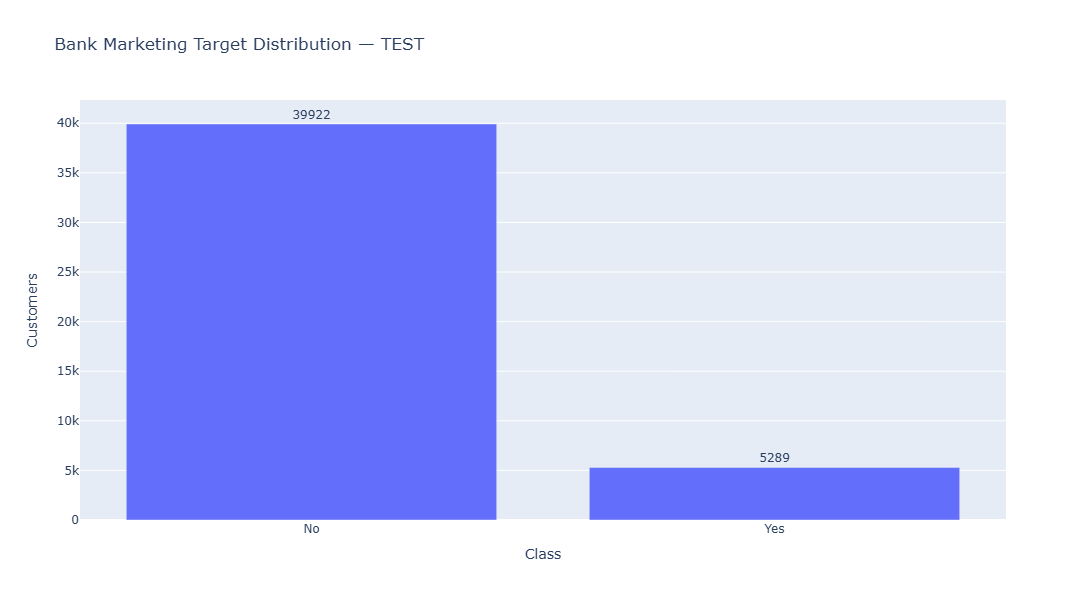


FILES CURRENTLY INSIDE results/plots
.ipynb_checkpoints                                           0 bytes
01_distribution_age.html                                     129,447 bytes
01_distribution_balance.html                                 611,391 bytes
01_distribution_campaign.html                                129,227 bytes
01_distribution_day.html                                     129,197 bytes
01_distribution_duration.html                                253,847 bytes
01_distribution_pdays.html                                   1,207,485 bytes
01_distribution_previous.html                                249,777 bytes
01_target_class_distribution.html                            8,304 bytes
02_age_by_target.html                                        299,986 bytes
02_balance_by_target.html                                    540,962 bytes
02_campaign_by_target.html                                   299,881 bytes
02_day_by_target.html                                        299,861

In [10]:
 # ================================================================
# PLOT OUTPUT TEST + PATH DIAGNOSTIC
# ================================================================

from pathlib import Path
import pandas as pd
import plotly.express as px
import os

print("=" * 80)
print("CHECKING PROJECT PATH")
print("=" * 80)

# Current Jupyter working directory
current_dir = Path.cwd()

print("Current Jupyter directory:")
print(current_dir)

# Expected project folders
project_root = current_dir.parent
results_dir = project_root / "results"
plots_dir = results_dir / "plots"

print("\nProject root:")
print(project_root)

print("\nResults directory:")
print(results_dir)

print("\nPlots directory:")
print(plots_dir)

# Create plots folder if it does not exist
plots_dir.mkdir(parents=True, exist_ok=True)

print("\n✓ Plots directory exists:")
print(plots_dir.exists())

# ================================================================
# CREATE A REAL TEST PLOT
# ================================================================

print("\n" + "=" * 80)
print("CREATING TEST PLOT")
print("=" * 80)

test_data = pd.DataFrame({
    "Class": ["No", "Yes"],
    "Customers": [39922, 5289]
})

fig = px.bar(
    test_data,
    x="Class",
    y="Customers",
    text="Customers",
    title="Bank Marketing Target Distribution — TEST"
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    width=900,
    height=600
)

# IMPORTANT:
# include_plotlyjs=True embeds Plotly directly inside the HTML.
# Therefore it does NOT depend on internet/CDN.

test_html = plots_dir / "TEST_bank_marketing_plot.html"

fig.write_html(
    str(test_html),
    include_plotlyjs=True,
    full_html=True
)

print("\n✓ Test HTML created:")
print(test_html)

print("\n✓ File exists:")
print(test_html.exists())

if test_html.exists():
    print("✓ File size:")
    print(f"{test_html.stat().st_size:,} bytes")

# ================================================================
# TRY PNG
# ================================================================

try:

    test_png = plots_dir / "TEST_bank_marketing_plot.png"

    fig.write_image(
        str(test_png),
        scale=2
    )

    print("\n✓ PNG created:")
    print(test_png)

except Exception as e:

    print("\n⚠ PNG was not created.")
    print("Reason:")
    print(e)

    print("\nThis normally means Kaleido is not installed.")
    print("HTML plot is still completely valid.")

# ================================================================
# SHOW THE PLOT DIRECTLY IN JUPYTER
# ================================================================

print("\n" + "=" * 80)
print("DISPLAYING TEST PLOT DIRECTLY IN JUPYTER")
print("=" * 80)

fig.show()

# ================================================================
# LIST EVERYTHING IN RESULTS/PLOTS
# ================================================================

print("\n" + "=" * 80)
print("FILES CURRENTLY INSIDE results/plots")
print("=" * 80)

plot_files = sorted(plots_dir.iterdir())

if len(plot_files) == 0:

    print("❌ Folder is empty.")

else:

    for file in plot_files:
        print(
            f"{file.name:<60} "
            f"{file.stat().st_size:,} bytes"
        )

print("\n" + "=" * 80)
print("FINAL PATH")
print("=" * 80)

print(plots_dir.resolve())

PROJECT PATH
C:\Users\Harsh\HPO_Explainable_Marketing

Plots will be saved to:
C:\Users\Harsh\HPO_Explainable_Marketing\results\plots

LOADING DATASET
Dataset shape: (45211, 17)

LOADING EXPERIMENT RESULTS
✓ Loaded: baseline_results.csv
✓ Loaded: imbalance_strategy_results.csv
✓ Loaded: imbalance_strategy_summary.csv
✓ Loaded: hpo_results.csv
✓ Loaded: multiobjective_pareto_results.csv
⚠ Missing: C:\Users\Harsh\HPO_Explainable_Marketing\results\metrics\threshold_results.csv
✓ Loaded: threshold_test_comparison.csv
✓ Loaded: robustness_summary.csv
✓ Loaded: xai_model_metrics.csv
✓ Loaded: final_model_comparison.csv
✓ Loaded: final_stage_summary.csv
✓ Loaded: paper_model_metrics.csv
✓ Loaded: global_shap_importance.csv
✓ Loaded: local_shap_explanation.csv
✓ Loaded: shap_stability_summary.csv
✓ Loaded: shap_stability_feature_summary.csv
✓ Loaded: shap_top10_overlap.csv
✓ Loaded: shap_spearman_stability.csv
✓ Loaded: shap_top10_frequency.csv
✓ Loaded: logistic_trials.csv
✓ Loaded: decision_

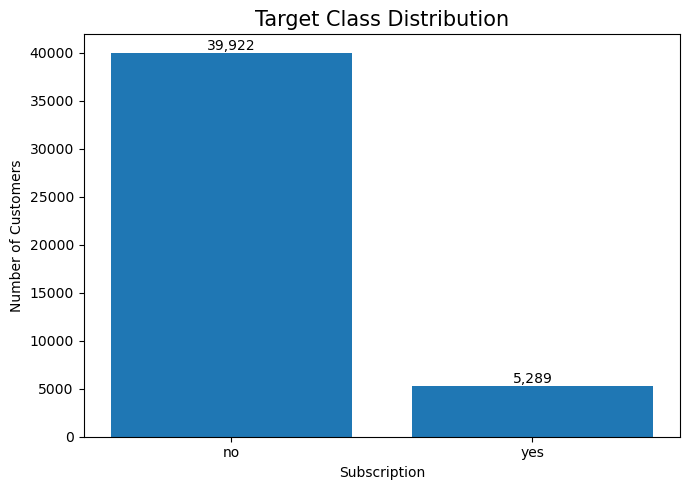

✓ Saved: 01_target_class_proportion.png


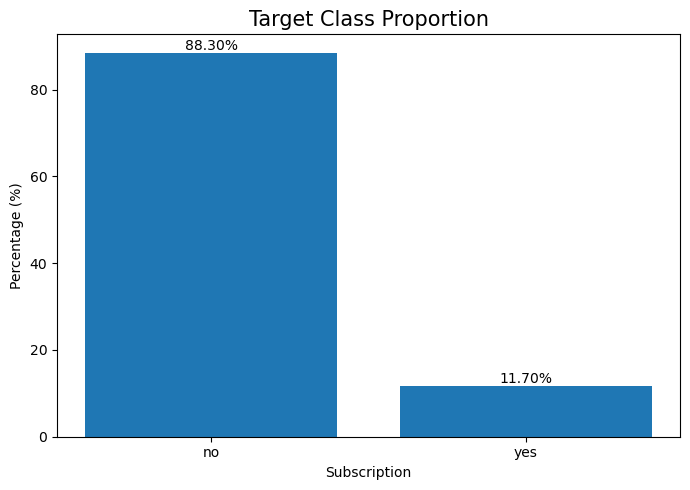

✓ Saved: 01_distribution_age.png


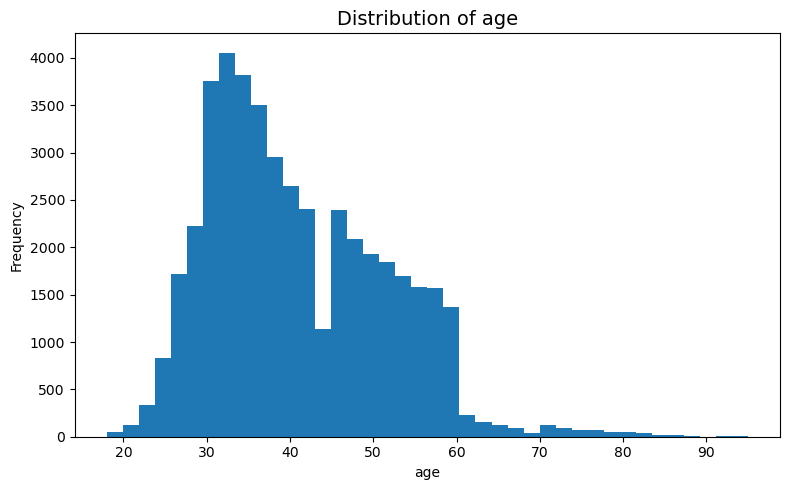

✓ Saved: 01_distribution_balance.png


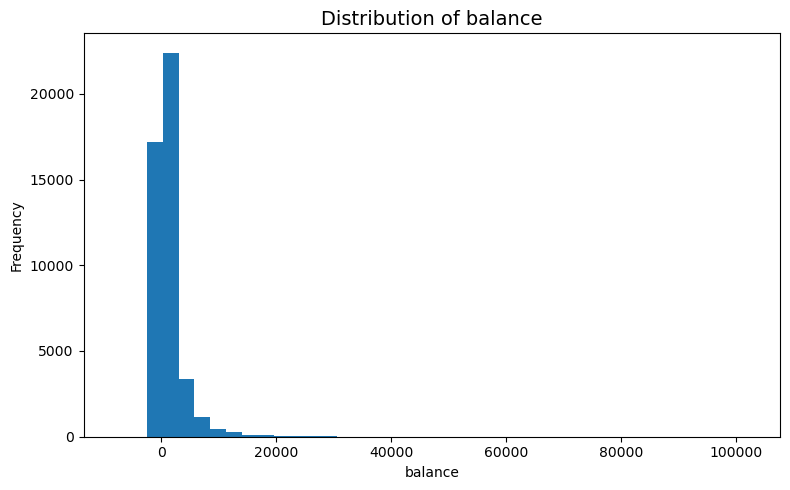

✓ Saved: 01_distribution_day.png


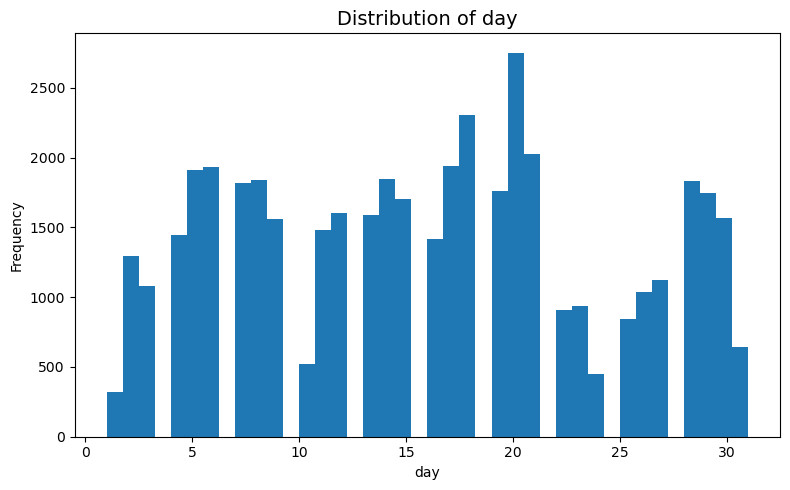

✓ Saved: 01_distribution_duration.png


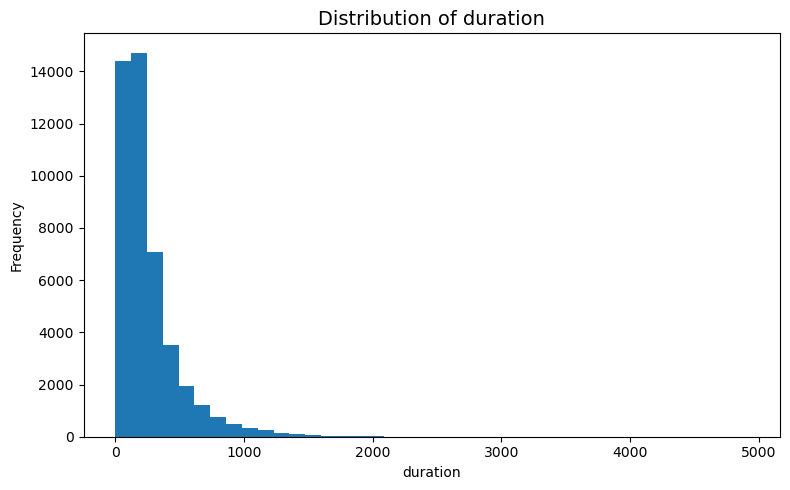

✓ Saved: 01_distribution_campaign.png


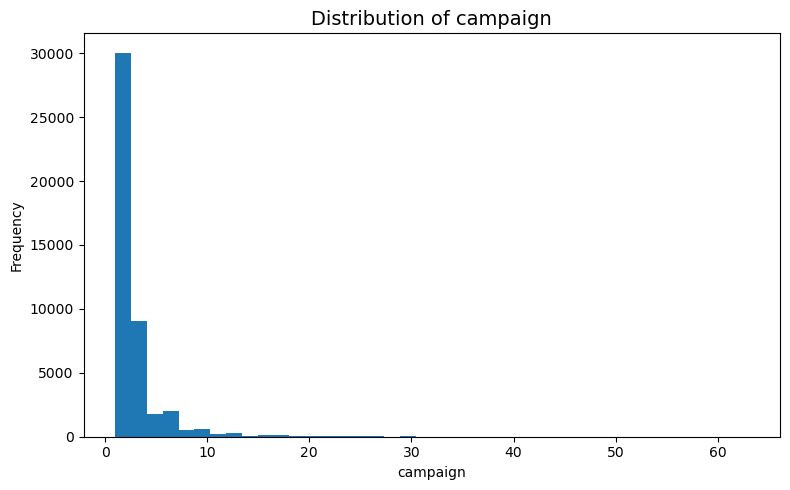

✓ Saved: 01_distribution_pdays.png


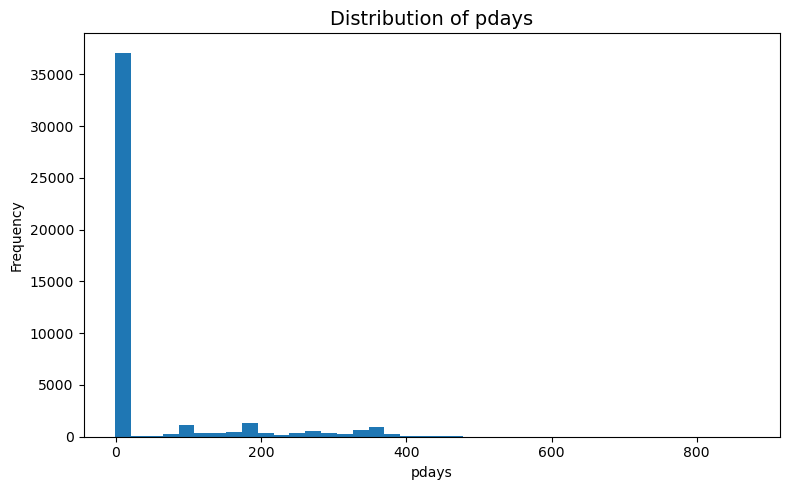

✓ Saved: 01_distribution_previous.png


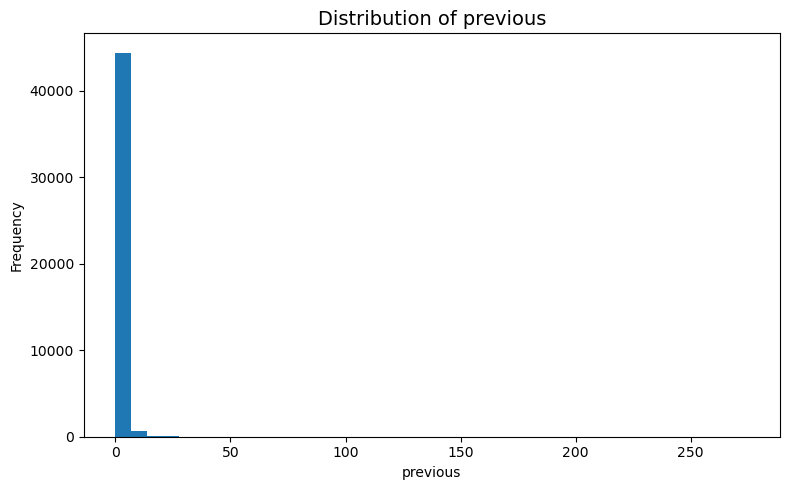


STAGE 2 — EDA + IMBALANCE
✓ Saved: 02_numeric_correlation_matrix.png


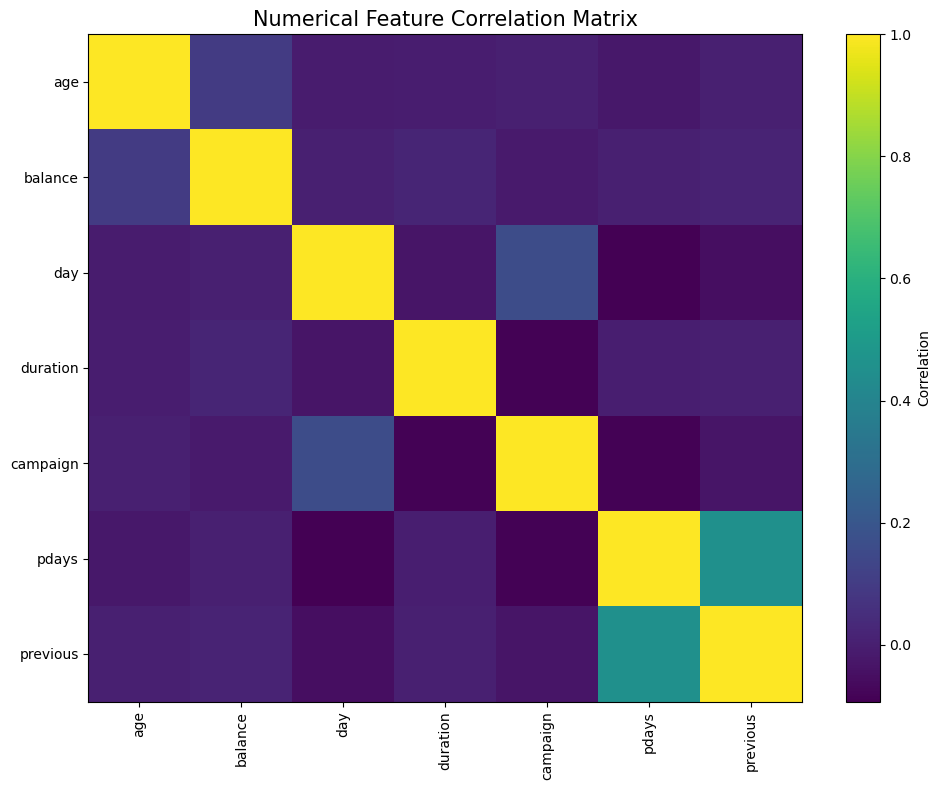

✓ Saved: 02_age_by_target.png


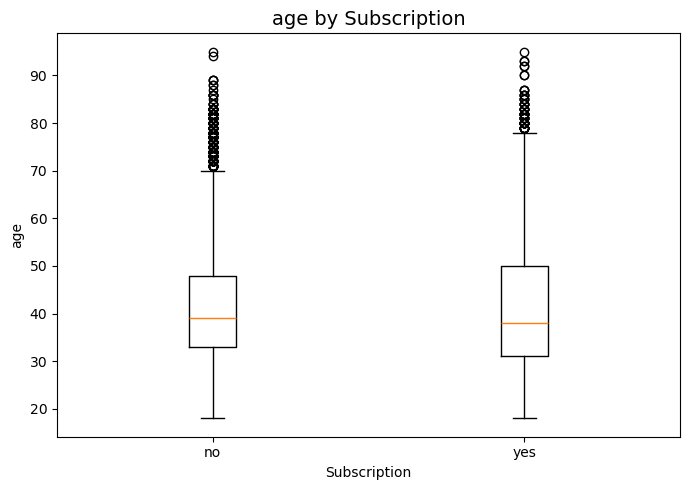

✓ Saved: 02_balance_by_target.png


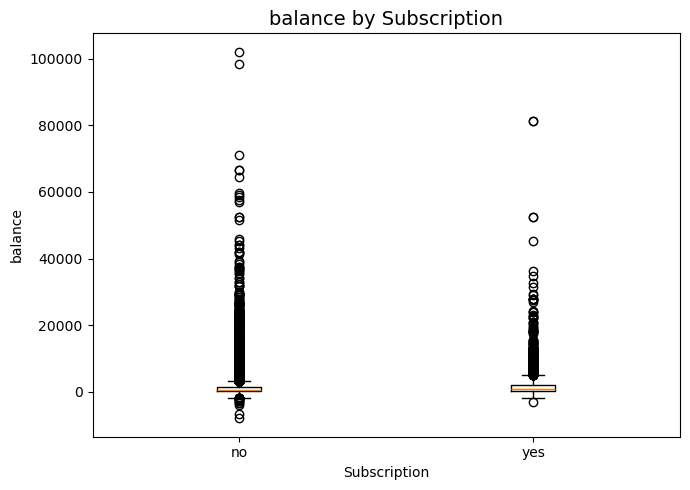

✓ Saved: 02_day_by_target.png


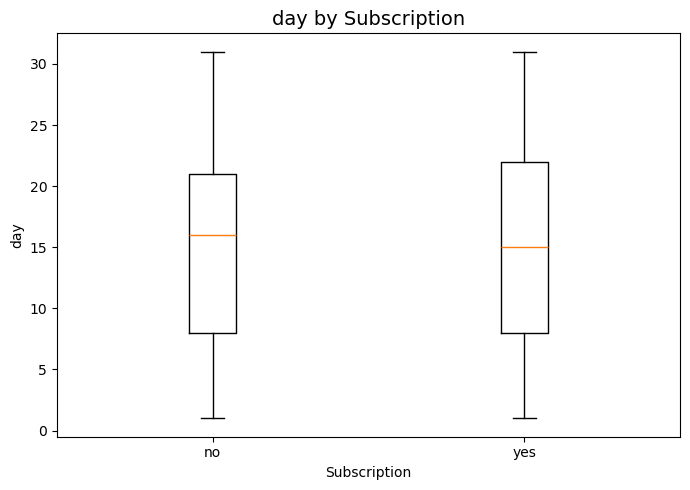

✓ Saved: 02_duration_by_target.png


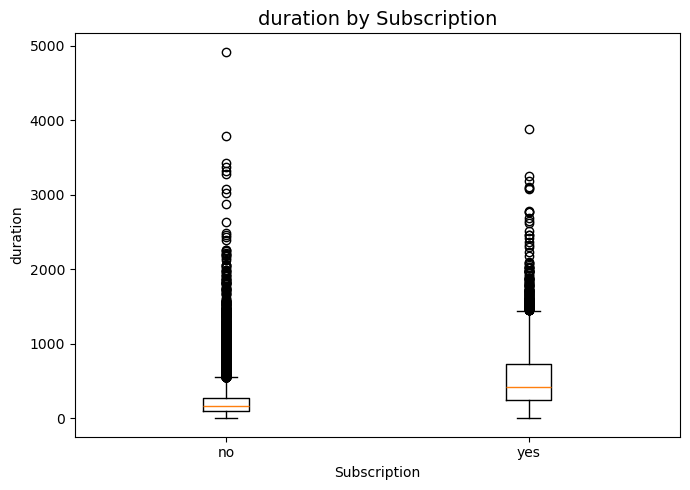

✓ Saved: 02_campaign_by_target.png


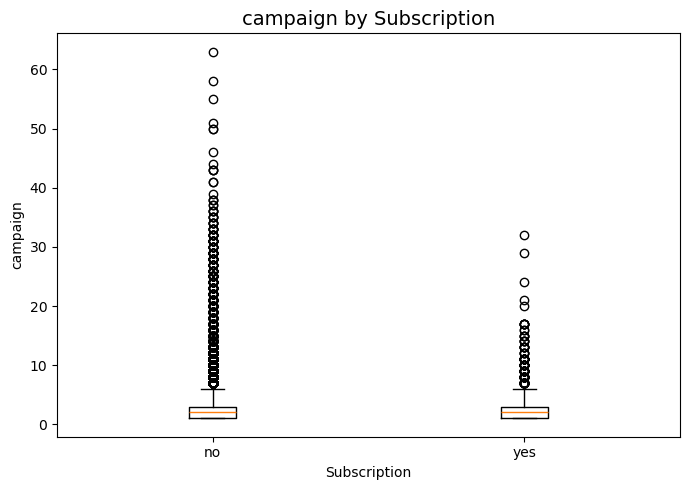

✓ Saved: 02_pdays_by_target.png


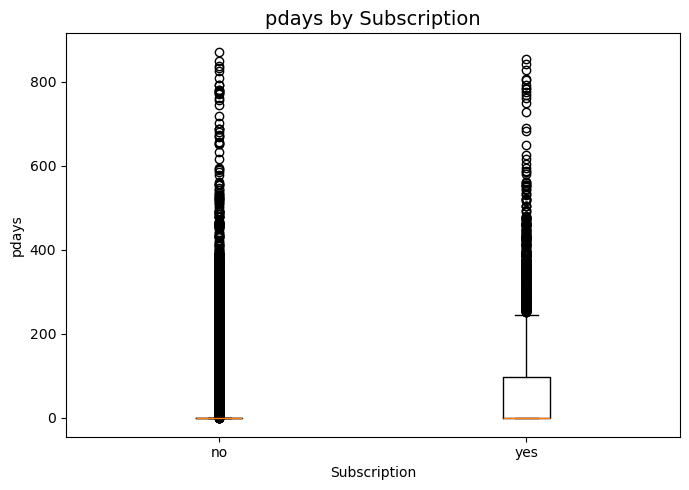

✓ Saved: 02_previous_by_target.png


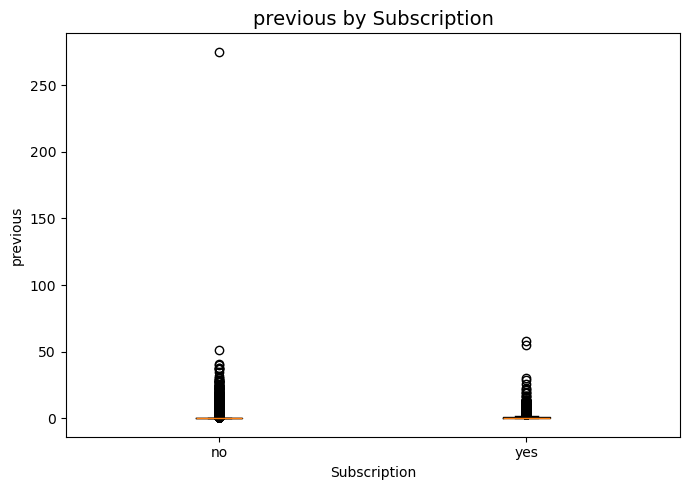

✓ Saved: 02_subscription_rate_job.png


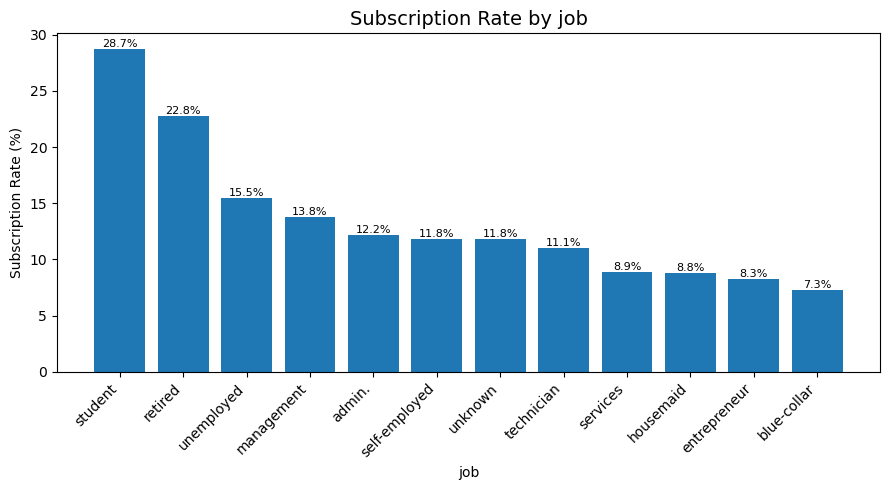

✓ Saved: 02_subscription_rate_marital.png


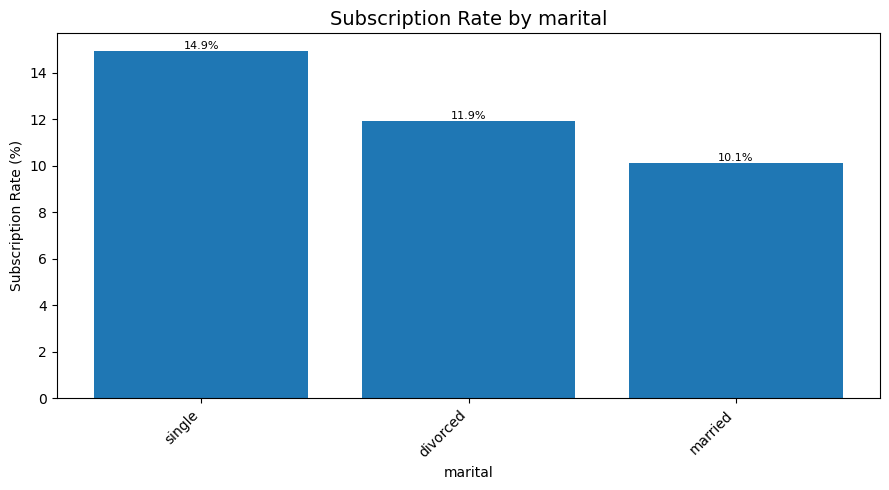

✓ Saved: 02_subscription_rate_education.png


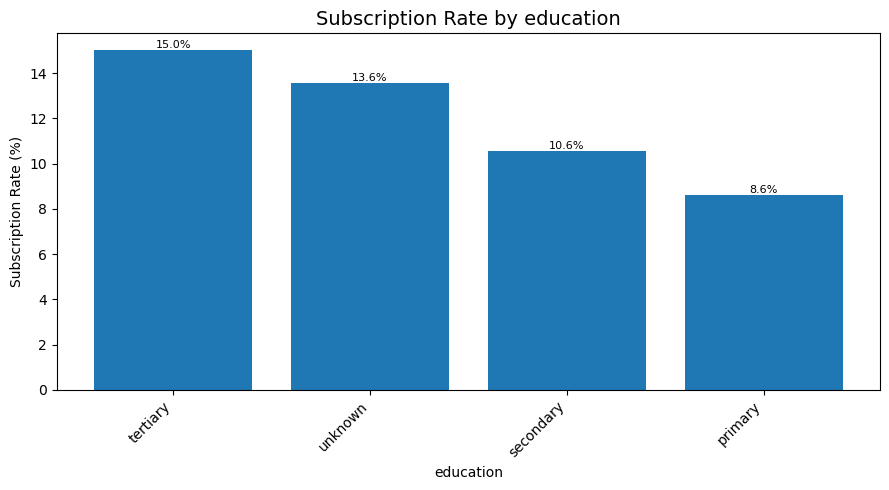

✓ Saved: 02_subscription_rate_default.png


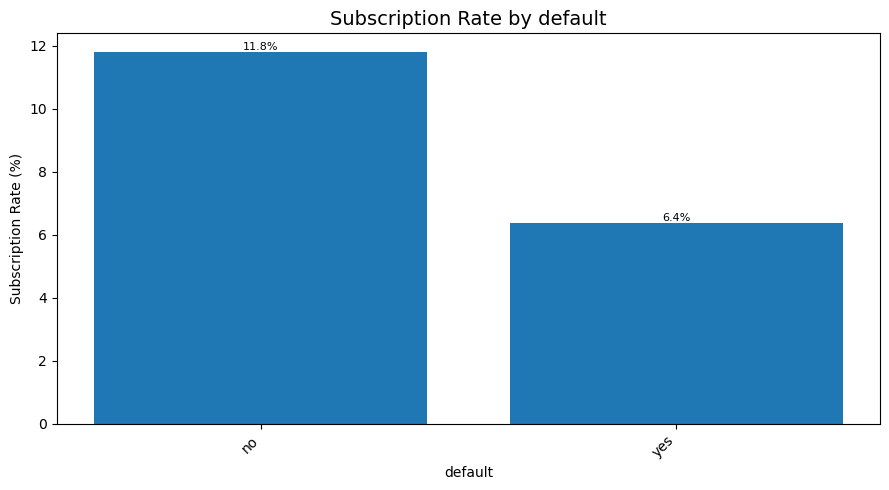

✓ Saved: 02_subscription_rate_housing.png


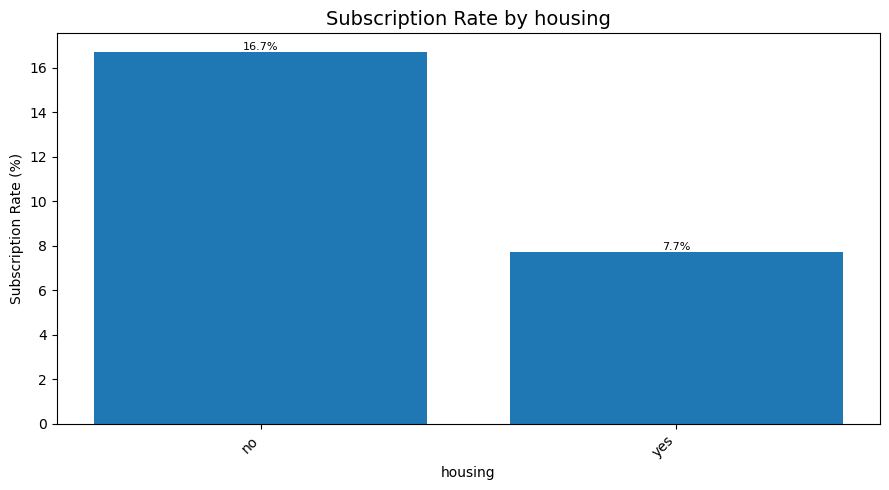

✓ Saved: 02_subscription_rate_loan.png


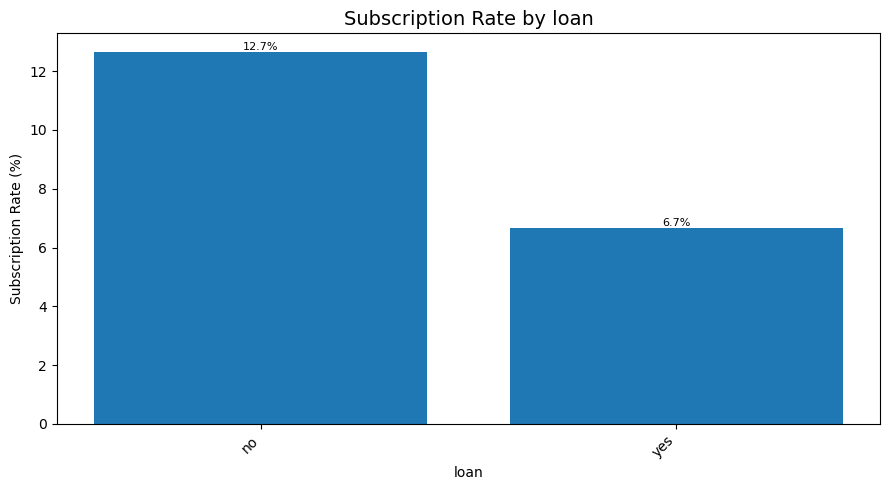

✓ Saved: 02_subscription_rate_contact.png


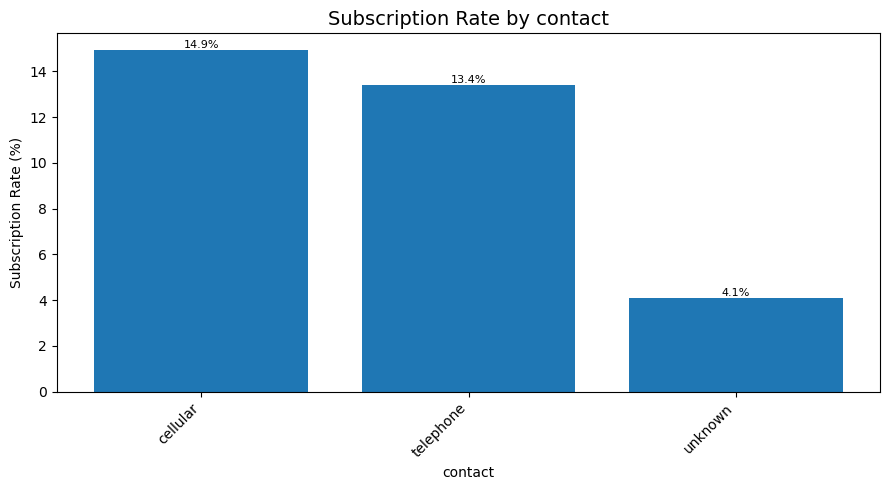

✓ Saved: 02_subscription_rate_month.png


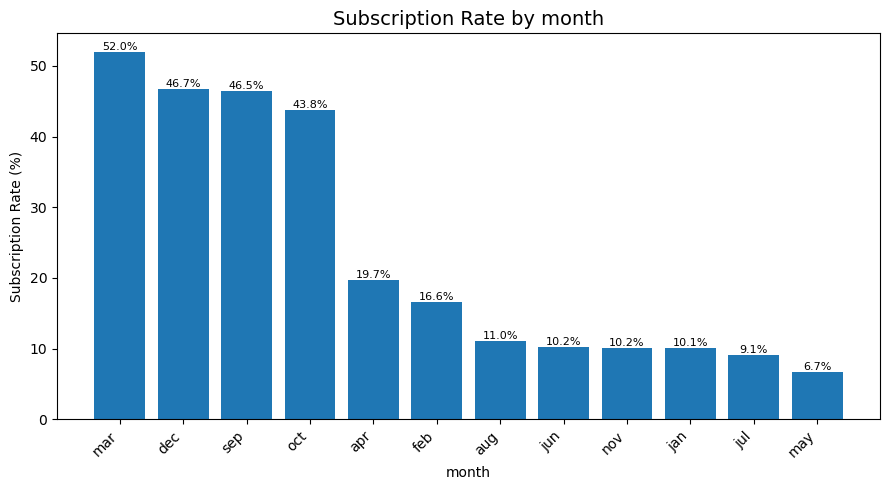

✓ Saved: 02_subscription_rate_poutcome.png


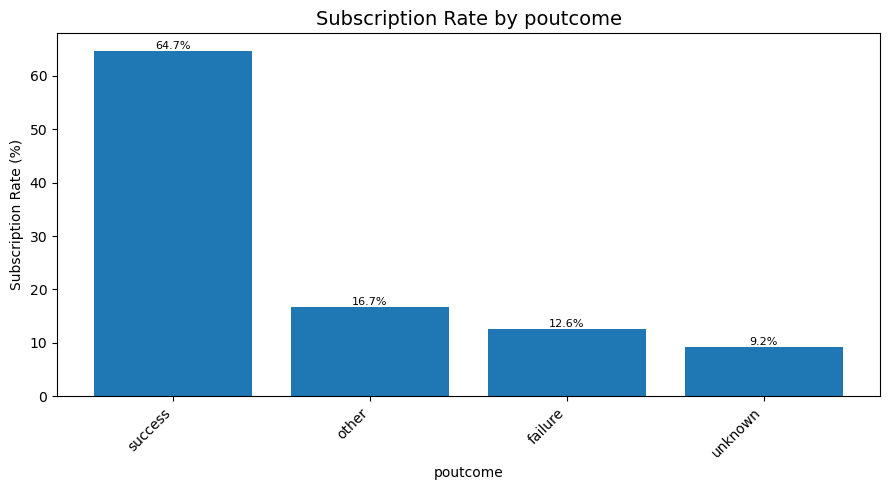


STAGE 3 — PREPROCESSING
✓ Saved: 03_train_test_distribution.png


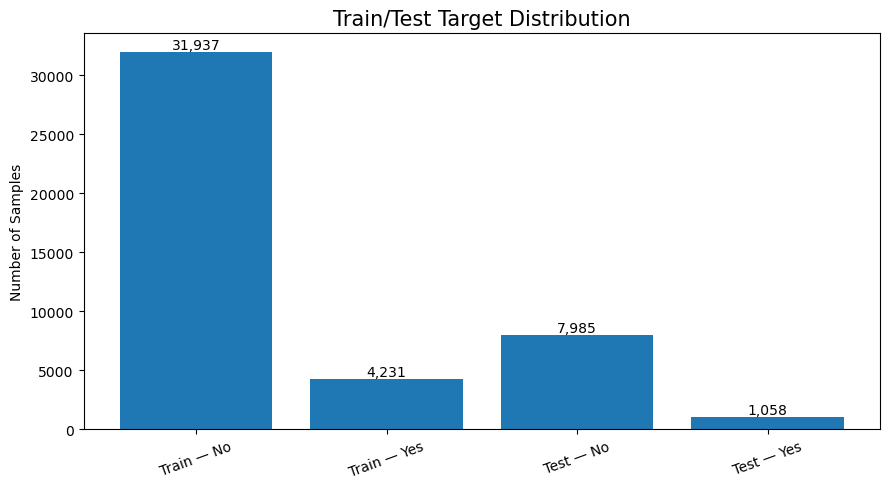


STAGE 4 — BASELINE MODELS
✓ Saved: 04_baseline_f1.png


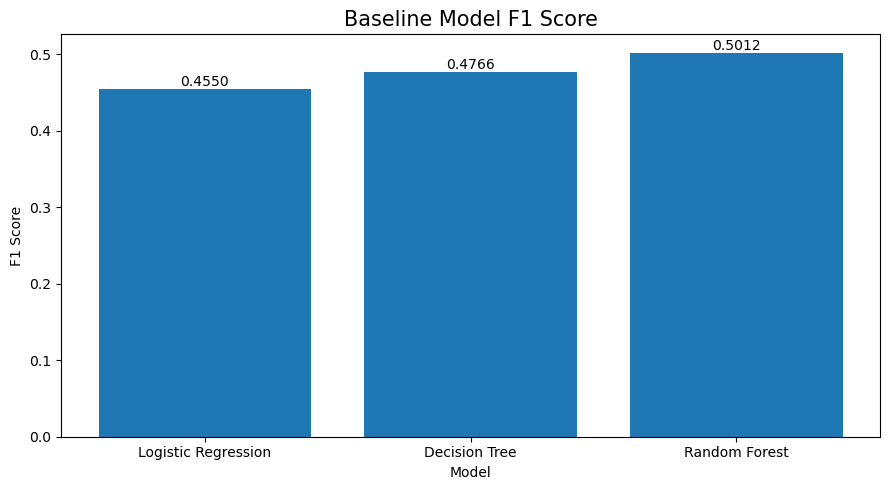

✓ Saved: 04_baseline_all_metrics.png


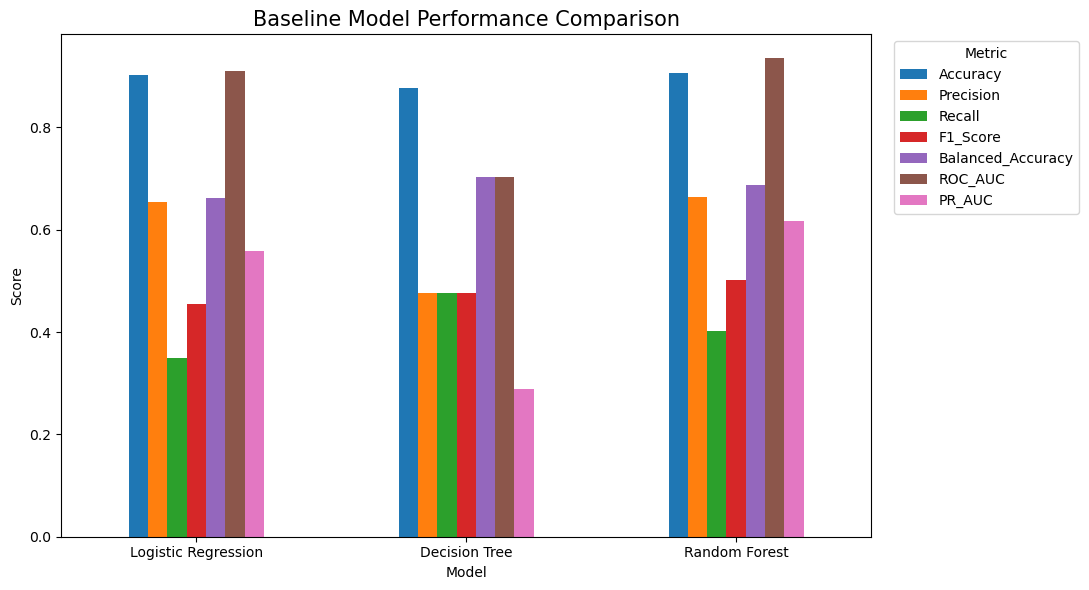


STAGE 5 — IMBALANCE STRATEGIES
✓ Saved: 05_imbalance_strategy_f1.png


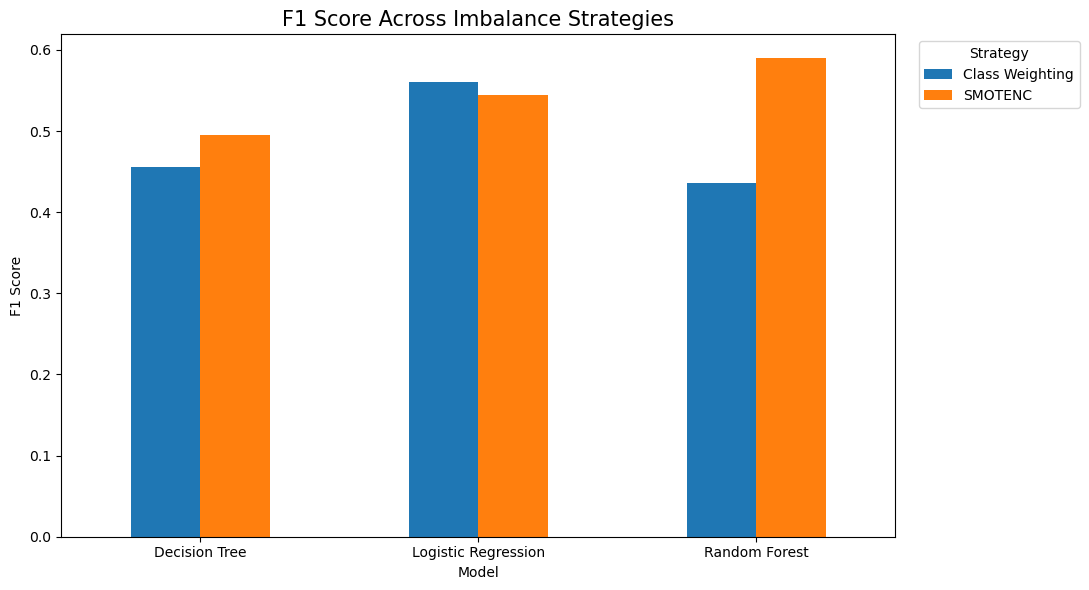

✓ Saved: 05_imbalance_strategy_recall.png


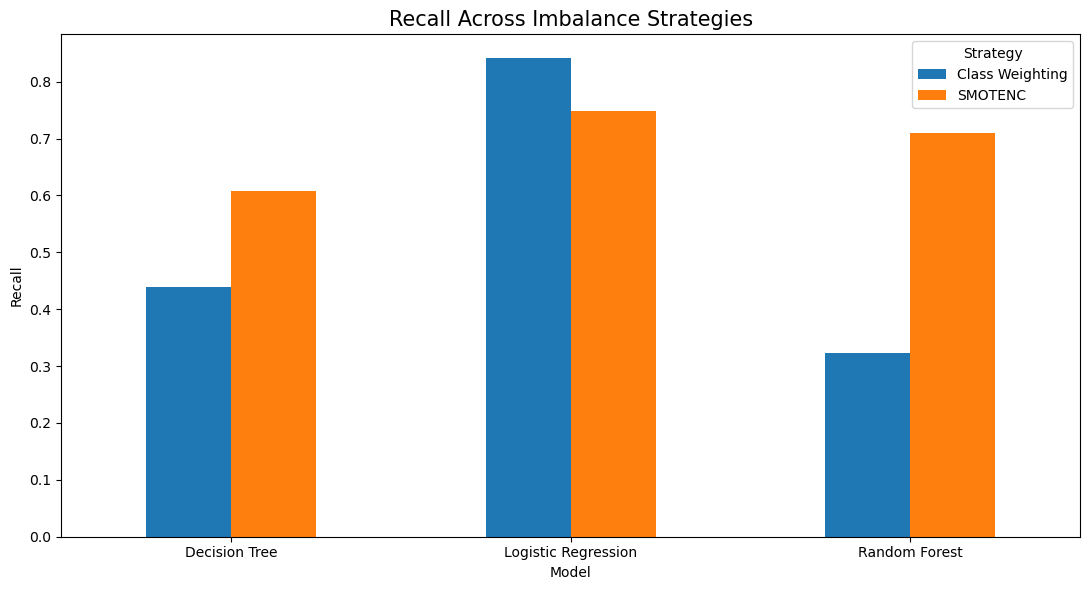


STAGE 6 — HYPERPARAMETER OPTIMIZATION
✓ Saved: 06_hpo_history_logistic_regression.png


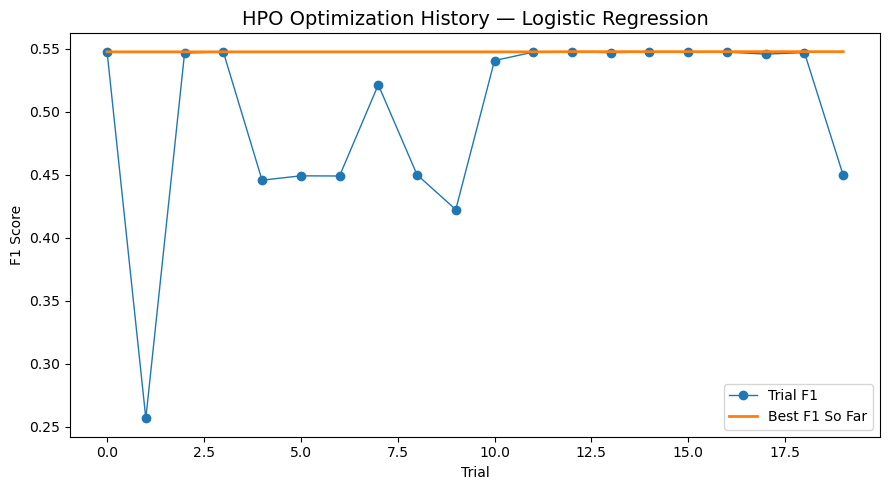

✓ Saved: 06_hpo_history_decision_tree.png


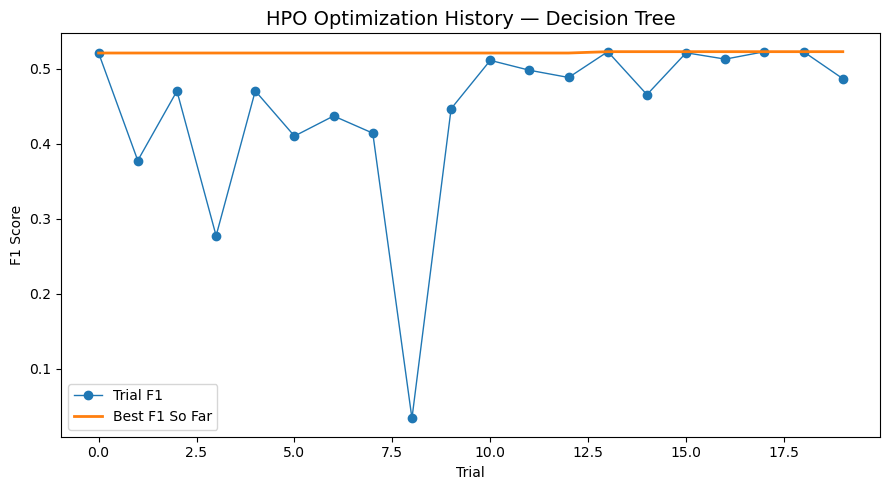

✓ Saved: 06_hpo_history_random_forest.png


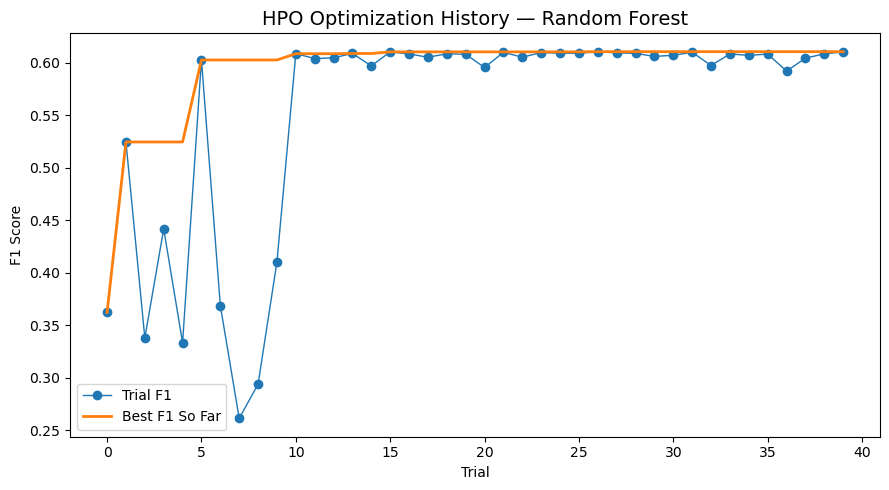

✓ Saved: 06_hpo_model_comparison.png


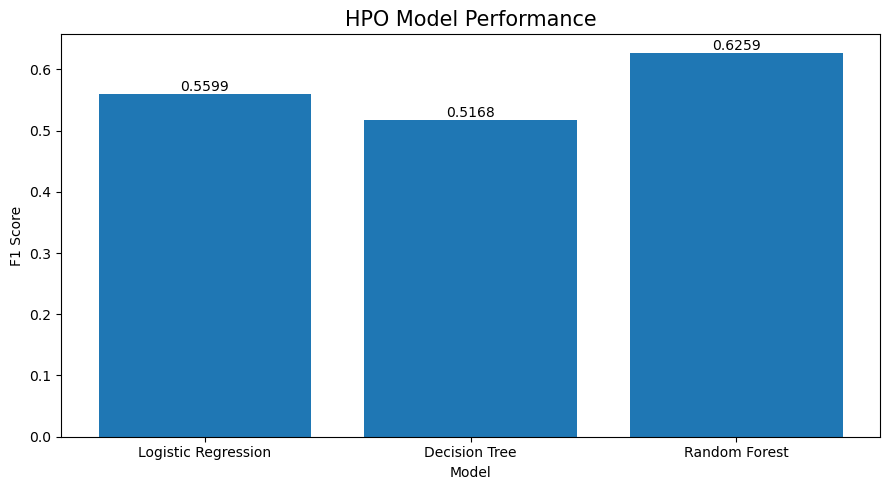


STAGE 7 — MULTI-OBJECTIVE HPO
✓ Saved: 07_pareto_logistic_regression.png


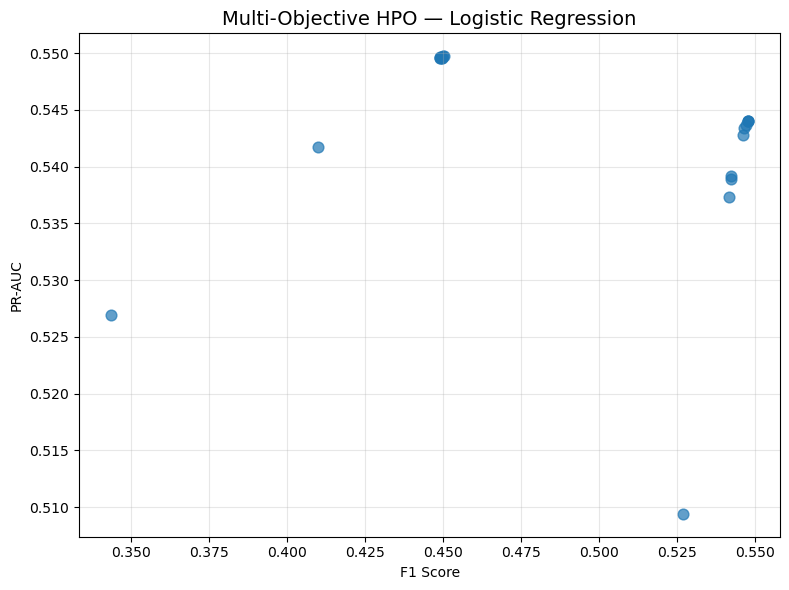

✓ Saved: 07_pareto_decision_tree.png


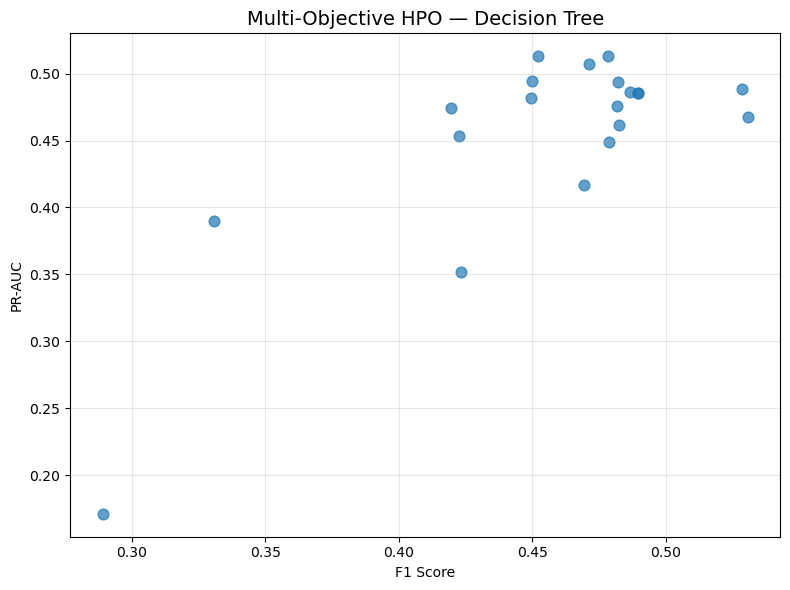

✓ Saved: 07_pareto_random_forest.png


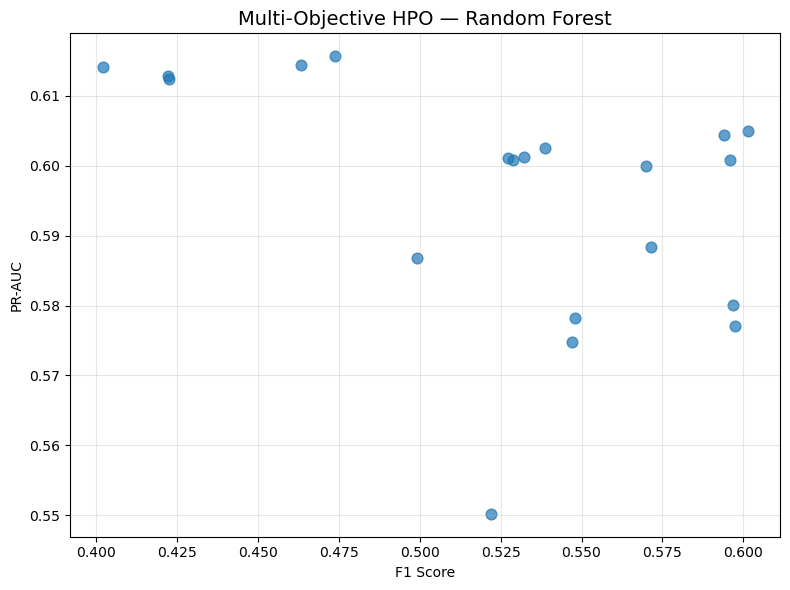

✓ Saved: 07_multiobjective_f1_vs_pr_auc.png


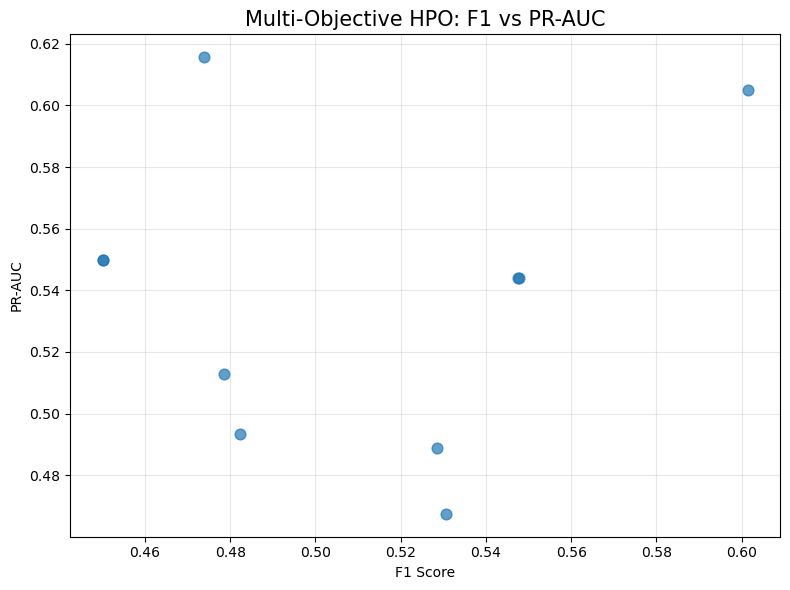


STAGE 8 — THRESHOLD OPTIMIZATION
✓ Saved: 08_default_vs_optimized_threshold.png


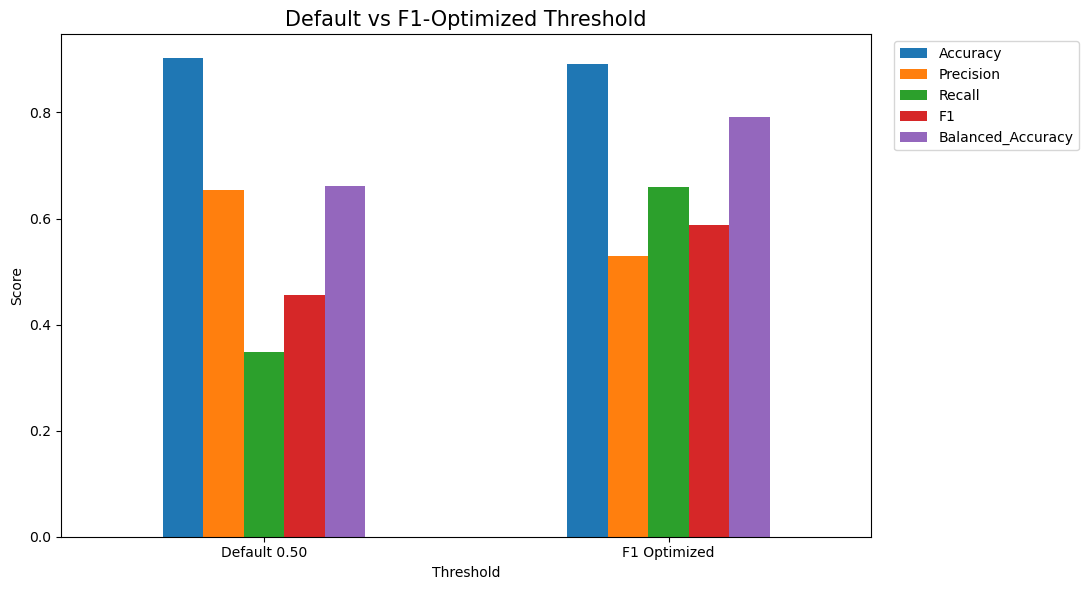


STAGE 9 — ROBUSTNESS ANALYSIS
✓ Saved: 09_robustness_mean_performance.png


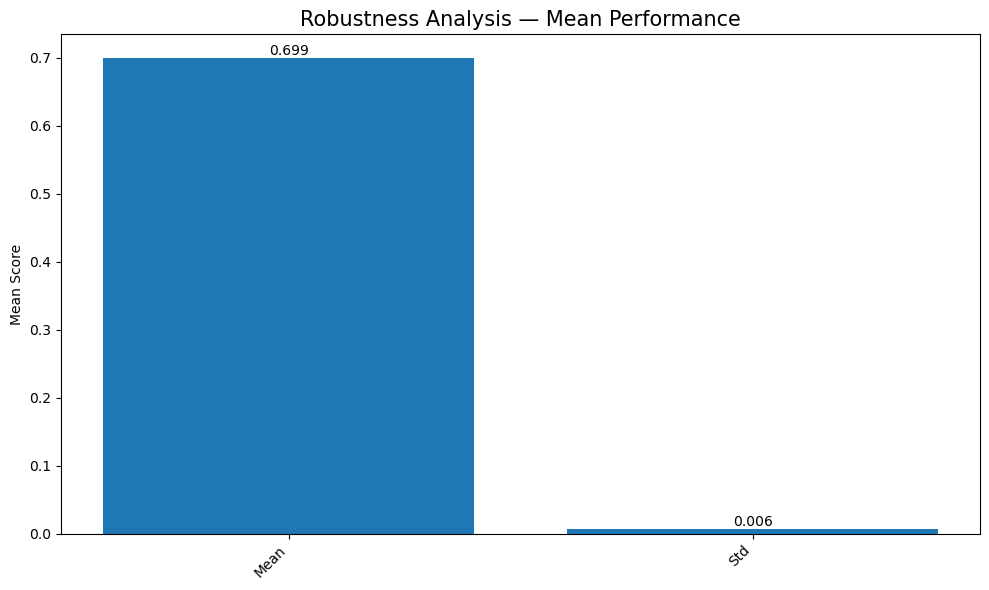


STAGE 10 — SHAP EXPLAINABILITY
✓ Saved: 10_global_shap_top20.png


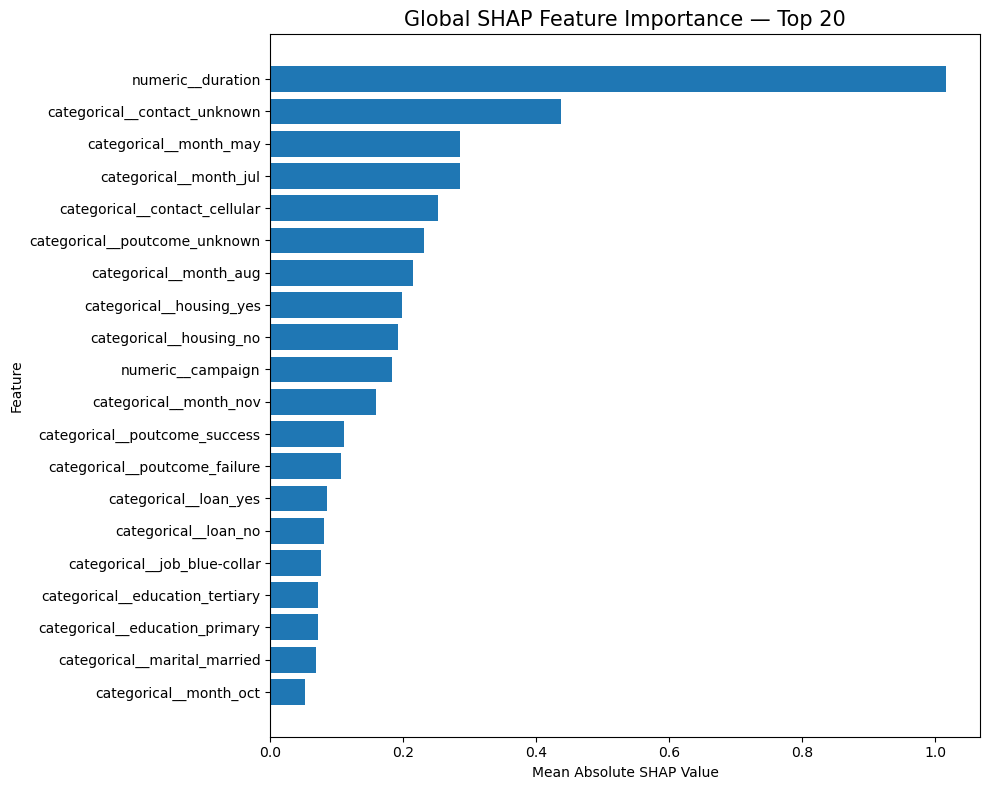

✓ Saved: 10_local_shap_explanation.png


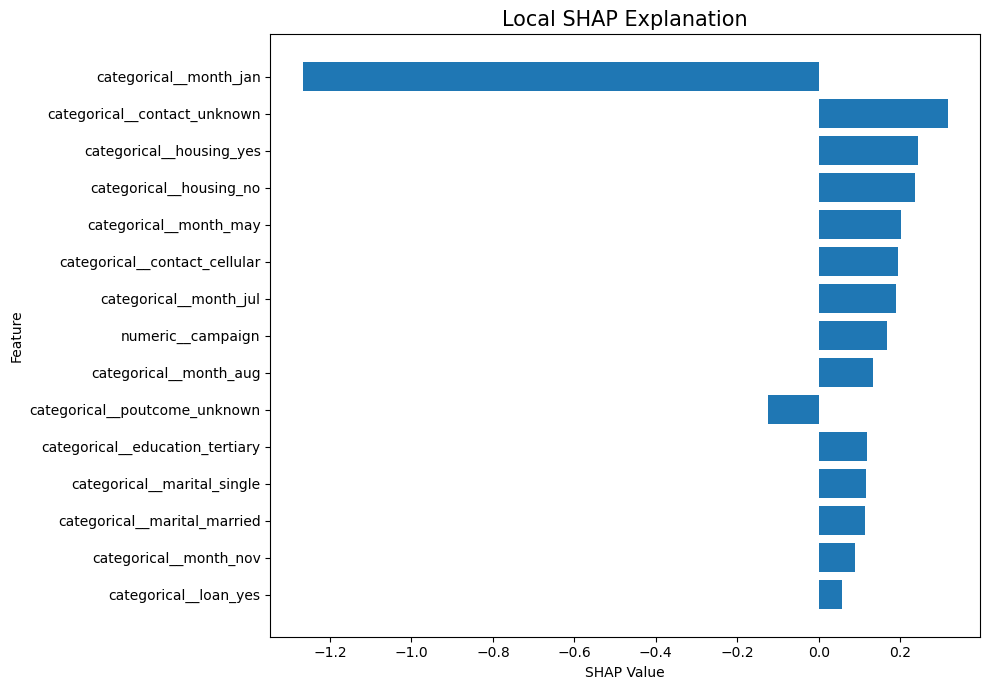


STAGE 11 — SHAP EXPLANATION STABILITY
✓ Saved: 11_shap_top10_overlap.png


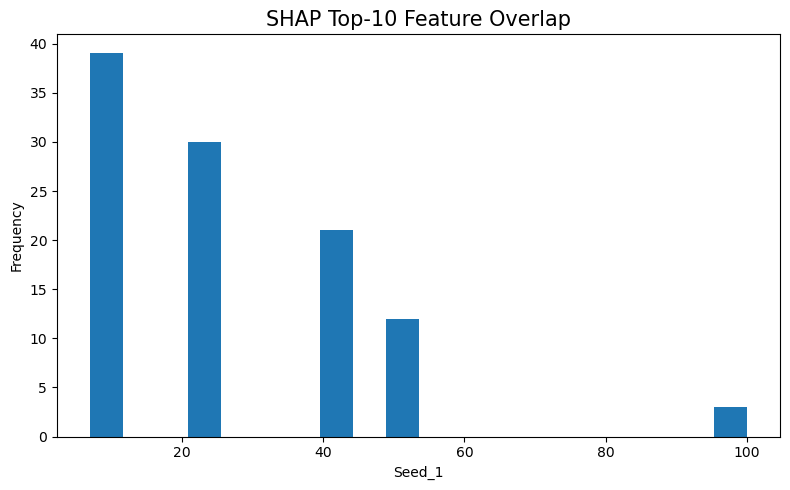

✓ Saved: 11_shap_spearman_stability.png


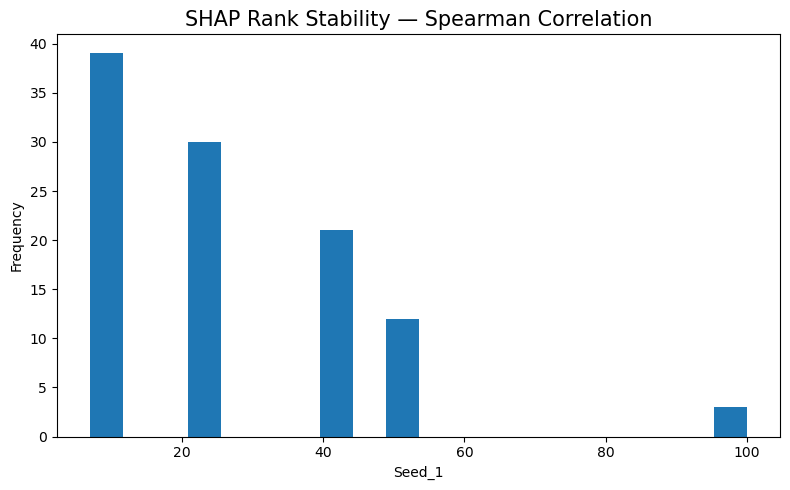


STAGE 12 — FINAL RESULTS
✓ Saved: 12_final_f1_comparison.png


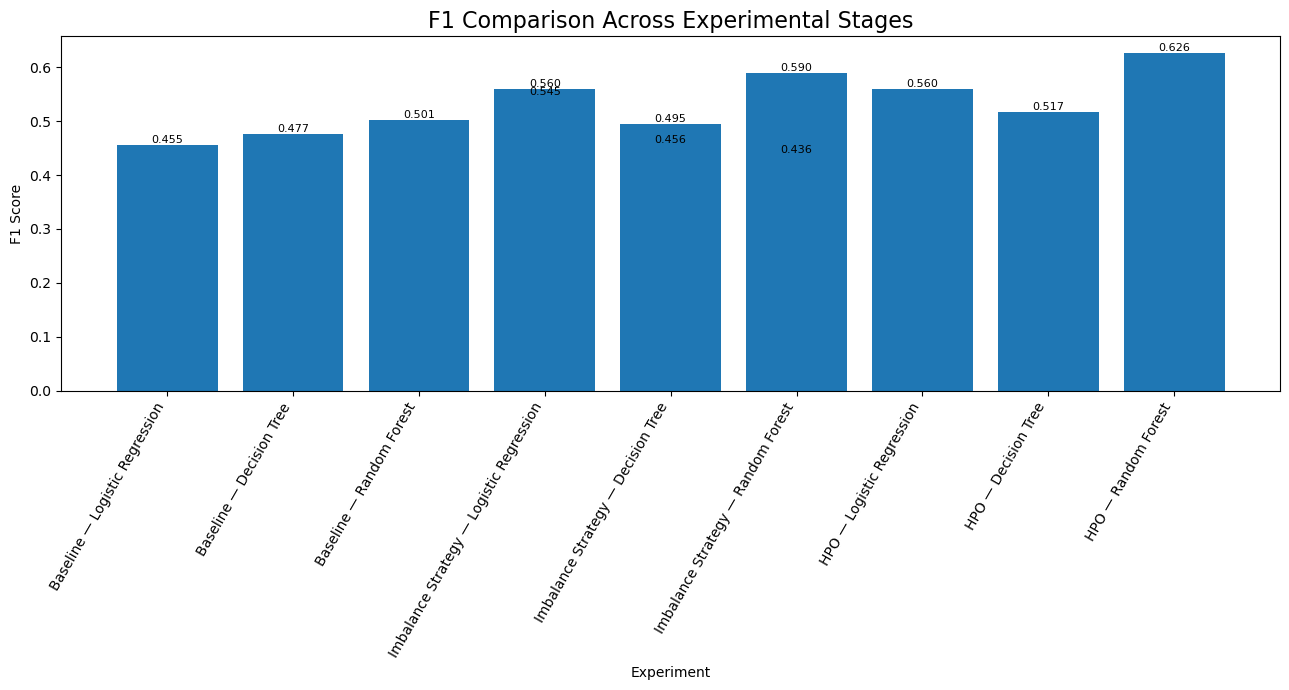

✓ Saved: 12_final_metrics_comparison.png


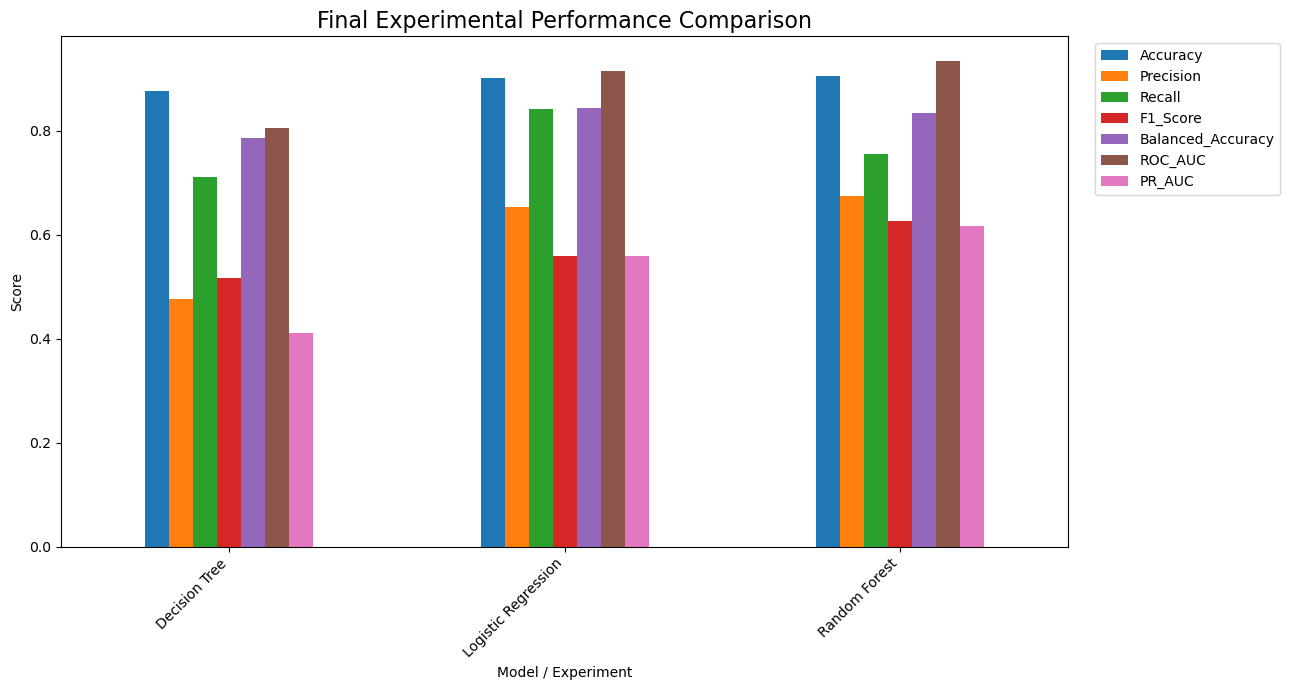


CREATING PLOT INDEX


ALL PNG PLOTS GENERATED

Total PNG plots: 47

Folder:
C:\Users\Harsh\HPO_Explainable_Marketing\results\plots

Files:
✓ 01_distribution_age.png
✓ 01_distribution_balance.png
✓ 01_distribution_campaign.png
✓ 01_distribution_day.png
✓ 01_distribution_duration.png
✓ 01_distribution_pdays.png
✓ 01_distribution_previous.png
✓ 01_target_class_distribution.png
✓ 01_target_class_proportion.png
✓ 02_age_by_target.png
✓ 02_balance_by_target.png
✓ 02_campaign_by_target.png
✓ 02_day_by_target.png
✓ 02_duration_by_target.png
✓ 02_numeric_correlation_matrix.png
✓ 02_pdays_by_target.png
✓ 02_previous_by_target.png
✓ 02_subscription_rate_contact.png
✓ 02_subscription_rate_default.png
✓ 02_subscription_rate_education.png
✓ 02_subscription_rate_housing.png
✓ 02_subscription_rate_job.png
✓ 02_subscription_rate_loan.png
✓ 02_subscription_rate_marital.png
✓ 02_subscription_rate_month.png
✓ 02_subscription_rate_poutcome.png
✓ 03_train_test_distribution.png
✓ 04_baseline_all_metrics.png

In [11]:
# ================================================================
# MASTER PAPER PLOT GENERATOR
# PNG VERSION — ALL 12 STAGES
# ================================================================

import os
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ================================================================
# 1. PATHS
# ================================================================

PROJECT_ROOT = Path.cwd().parent

RESULTS_DIR = PROJECT_ROOT / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
HPO_DIR = RESULTS_DIR / "hpo"
SHAP_DIR = RESULTS_DIR / "shap"
PLOTS_DIR = RESULTS_DIR / "plots"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("PROJECT PATH")
print("=" * 80)
print(PROJECT_ROOT)

print("\nPlots will be saved to:")
print(PLOTS_DIR)


# ================================================================
# 2. HELPER FUNCTIONS
# ================================================================

plot_number = 0


def save_fig(filename):
    """
    Save current Matplotlib figure as a high-resolution PNG.
    """
    
    global plot_number
    
    path = PLOTS_DIR / filename
    
    plt.tight_layout()
    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )
    
    plot_number += 1
    
    print(f"✓ Saved: {filename}")
    
    plt.show()
    plt.close()


def load_csv(filename, folder):
    """
    Safely load a CSV file.
    """
    
    path = folder / filename
    
    if not path.exists():
        print(f"⚠ Missing: {path}")
        return None
    
    try:
        data = pd.read_csv(path)
        print(f"✓ Loaded: {filename}")
        return data
    
    except Exception as e:
        print(f"⚠ Error reading {filename}: {e}")
        return None


def find_column(df, candidates):
    """
    Find the first matching column.
    """
    
    if df is None:
        return None
    
    for col in candidates:
        if col in df.columns:
            return col
    
    return None


def numeric_columns(df):
    """
    Return numeric columns.
    """
    
    if df is None:
        return []
    
    return df.select_dtypes(
        include=np.number
    ).columns.tolist()


# ================================================================
# 3. LOAD DATASET
# ================================================================

print("\n" + "=" * 80)
print("LOADING DATASET")
print("=" * 80)

data_path = PROJECT_ROOT / "data" / "raw" / "bank-full.csv"

if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{data_path}"
    )

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)


# ================================================================
# 4. LOAD RESULT FILES
# ================================================================

print("\n" + "=" * 80)
print("LOADING EXPERIMENT RESULTS")
print("=" * 80)

baseline = load_csv(
    "baseline_results.csv",
    METRICS_DIR
)

imbalance = load_csv(
    "imbalance_strategy_results.csv",
    METRICS_DIR
)

imbalance_summary = load_csv(
    "imbalance_strategy_summary.csv",
    METRICS_DIR
)

hpo = load_csv(
    "hpo_results.csv",
    METRICS_DIR
)

multiobjective = load_csv(
    "multiobjective_pareto_results.csv",
    METRICS_DIR
)

threshold = load_csv(
    "threshold_results.csv",
    METRICS_DIR
)

threshold_comparison = load_csv(
    "threshold_test_comparison.csv",
    METRICS_DIR
)

robustness = load_csv(
    "robustness_summary.csv",
    METRICS_DIR
)

xai_metrics = load_csv(
    "xai_model_metrics.csv",
    METRICS_DIR
)

final_comparison = load_csv(
    "final_model_comparison.csv",
    METRICS_DIR
)

final_summary = load_csv(
    "final_stage_summary.csv",
    METRICS_DIR
)

paper_metrics = load_csv(
    "paper_model_metrics.csv",
    METRICS_DIR
)

global_shap = load_csv(
    "global_shap_importance.csv",
    SHAP_DIR
)

local_shap = load_csv(
    "local_shap_explanation.csv",
    SHAP_DIR
)

shap_stability = load_csv(
    "shap_stability_summary.csv",
    SHAP_DIR
)

shap_feature_stability = load_csv(
    "shap_stability_feature_summary.csv",
    SHAP_DIR
)

shap_overlap = load_csv(
    "shap_top10_overlap.csv",
    SHAP_DIR
)

shap_spearman = load_csv(
    "shap_spearman_stability.csv",
    SHAP_DIR
)

shap_frequency = load_csv(
    "shap_top10_frequency.csv",
    SHAP_DIR
)

logistic_trials = load_csv(
    "logistic_trials.csv",
    HPO_DIR
)

tree_trials = load_csv(
    "decision_tree_trials.csv",
    HPO_DIR
)

rf_trials = load_csv(
    "random_forest_trials.csv",
    HPO_DIR
)

logistic_multi = load_csv(
    "logistic_multiobjective_trials.csv",
    HPO_DIR
)

tree_multi = load_csv(
    "decision_tree_multiobjective_trials.csv",
    HPO_DIR
)

rf_multi = load_csv(
    "random_forest_multiobjective_trials.csv",
    HPO_DIR
)


# ================================================================
# STAGE 1
# DATA UNDERSTANDING
# ================================================================

print("\n" + "=" * 80)
print("STAGE 1 — DATA UNDERSTANDING")
print("=" * 80)


# ------------------------------------------------
# PLOT 1 — TARGET DISTRIBUTION
# ------------------------------------------------

if "y" in df.columns:

    counts = df["y"].value_counts()

    plt.figure(figsize=(7, 5))

    bars = plt.bar(
        counts.index,
        counts.values
    )

    plt.title(
        "Target Class Distribution",
        fontsize=15
    )

    plt.xlabel("Subscription")
    plt.ylabel("Number of Customers")

    for bar, value in zip(
        bars,
        counts.values
    ):
        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            value,
            f"{value:,}",
            ha="center",
            va="bottom"
        )

    save_fig(
        "01_target_class_distribution.png"
    )


# ------------------------------------------------
# PLOT 2 — TARGET PERCENTAGE
# ------------------------------------------------

if "y" in df.columns:

    percentages = (
        df["y"]
        .value_counts(normalize=True)
        * 100
    )

    plt.figure(figsize=(7, 5))

    bars = plt.bar(
        percentages.index,
        percentages.values
    )

    plt.title(
        "Target Class Proportion",
        fontsize=15
    )

    plt.xlabel("Subscription")
    plt.ylabel("Percentage (%)")

    for bar, value in zip(
        bars,
        percentages.values
    ):
        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            value,
            f"{value:.2f}%",
            ha="center",
            va="bottom"
        )

    save_fig(
        "01_target_class_proportion.png"
    )


# ------------------------------------------------
# PLOT 3 — NUMERICAL FEATURE DISTRIBUTIONS
# ------------------------------------------------

numeric_features = df.select_dtypes(
    include=np.number
).columns.tolist()

for feature in numeric_features:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[feature].dropna(),
        bins=40
    )

    plt.title(
        f"Distribution of {feature}",
        fontsize=14
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")

    save_fig(
        f"01_distribution_{feature}.png"
    )


# ================================================================
# STAGE 2
# EDA + IMBALANCE
# ================================================================

print("\n" + "=" * 80)
print("STAGE 2 — EDA + IMBALANCE")
print("=" * 80)


# ------------------------------------------------
# PLOT 4 — CORRELATION MATRIX
# ------------------------------------------------

if len(numeric_features) >= 2:

    corr = df[numeric_features].corr()

    plt.figure(
        figsize=(10, 8)
    )

    plt.imshow(
        corr,
        interpolation="nearest",
        aspect="auto"
    )

    plt.colorbar(
        label="Correlation"
    )

    plt.xticks(
        range(len(corr.columns)),
        corr.columns,
        rotation=90
    )

    plt.yticks(
        range(len(corr.columns)),
        corr.columns
    )

    plt.title(
        "Numerical Feature Correlation Matrix",
        fontsize=15
    )

    save_fig(
        "02_numeric_correlation_matrix.png"
    )


# ------------------------------------------------
# PLOT 5 — NUMERICAL FEATURES BY TARGET
# ------------------------------------------------

if "y" in df.columns:

    for feature in numeric_features:

        groups = []

        labels = []

        for target_value in ["no", "yes"]:

            if target_value in df["y"].unique():

                groups.append(
                    df.loc[
                        df["y"] == target_value,
                        feature
                    ].dropna()
                )

                labels.append(
                    target_value
                )

        if len(groups) == 2:

            plt.figure(
                figsize=(7, 5)
            )

            plt.boxplot(
                groups,
                labels=labels
            )

            plt.title(
                f"{feature} by Subscription",
                fontsize=14
            )

            plt.xlabel("Subscription")
            plt.ylabel(feature)

            save_fig(
                f"02_{feature}_by_target.png"
            )


# ------------------------------------------------
# PLOT 6 — CATEGORICAL SUBSCRIPTION RATES
# ------------------------------------------------

categorical_features = df.select_dtypes(
    exclude=np.number
).columns.tolist()

if "y" in categorical_features:
    categorical_features.remove("y")

for feature in categorical_features:

    if df[feature].nunique() <= 15:

        rate = (
            df.groupby(feature)["y"]
            .apply(
                lambda x:
                (x == "yes").mean() * 100
            )
            .sort_values(
                ascending=False
            )
        )

        plt.figure(
            figsize=(9, 5)
        )

        bars = plt.bar(
            rate.index.astype(str),
            rate.values
        )

        plt.title(
            f"Subscription Rate by {feature}",
            fontsize=14
        )

        plt.xlabel(feature)
        plt.ylabel(
            "Subscription Rate (%)"
        )

        plt.xticks(
            rotation=45,
            ha="right"
        )

        for bar, value in zip(
            bars,
            rate.values
        ):
            plt.text(
                bar.get_x()
                + bar.get_width() / 2,
                value,
                f"{value:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8
            )

        save_fig(
            f"02_subscription_rate_{feature}.png"
        )


# ================================================================
# STAGE 3
# PREPROCESSING
# ================================================================

print("\n" + "=" * 80)
print("STAGE 3 — PREPROCESSING")
print("=" * 80)


# ------------------------------------------------
# PLOT 7 — TRAIN/TEST TARGET DISTRIBUTION
# ------------------------------------------------

from sklearn.model_selection import train_test_split

X = df.drop(
    columns=["y"]
)

y = df["y"].map({
    "no": 0,
    "yes": 1
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

train_counts = y_train.value_counts()
test_counts = y_test.value_counts()

labels = [
    "Train — No",
    "Train — Yes",
    "Test — No",
    "Test — Yes"
]

values = [
    train_counts.get(0, 0),
    train_counts.get(1, 0),
    test_counts.get(0, 0),
    test_counts.get(1, 0)
]

plt.figure(
    figsize=(9, 5)
)

bars = plt.bar(
    labels,
    values
)

plt.title(
    "Train/Test Target Distribution",
    fontsize=15
)

plt.ylabel("Number of Samples")

plt.xticks(
    rotation=20
)

for bar, value in zip(
    bars,
    values
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

save_fig(
    "03_train_test_distribution.png"
)


# ================================================================
# STAGE 4
# BASELINE MODELS
# ================================================================

print("\n" + "=" * 80)
print("STAGE 4 — BASELINE MODELS")
print("=" * 80)


if baseline is not None:

    f1_col = find_column(
        baseline,
        [
            "F1",
            "F1_Score"
        ]
    )

    model_col = find_column(
        baseline,
        [
            "Model",
            "model"
        ]
    )

    if f1_col and model_col:

        plt.figure(
            figsize=(9, 5)
        )

        bars = plt.bar(
            baseline[model_col],
            baseline[f1_col]
        )

        plt.title(
            "Baseline Model F1 Score",
            fontsize=15
        )

        plt.xlabel("Model")
        plt.ylabel("F1 Score")

        for bar, value in zip(
            bars,
            baseline[f1_col]
        ):
            plt.text(
                bar.get_x()
                + bar.get_width() / 2,
                value,
                f"{value:.4f}",
                ha="center",
                va="bottom"
            )

        save_fig(
            "04_baseline_f1.png"
        )


    # ------------------------------------------------
    # PLOT 8 — BASELINE METRICS
    # ------------------------------------------------

    metric_candidates = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "F1_Score",
        "Balanced_Accuracy",
        "ROC_AUC",
        "PR_AUC"
    ]

    available = [
        c for c in metric_candidates
        if c in baseline.columns
    ]

    if model_col and available:

        plot_df = baseline[
            [model_col] + available
        ].copy()

        plot_df = plot_df.set_index(
            model_col
        )

        ax = plot_df.plot(
            kind="bar",
            figsize=(11, 6)
        )

        ax.set_title(
            "Baseline Model Performance Comparison",
            fontsize=15
        )

        ax.set_xlabel("Model")
        ax.set_ylabel("Score")

        plt.xticks(
            rotation=0
        )

        plt.legend(
            title="Metric",
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

        save_fig(
            "04_baseline_all_metrics.png"
        )


# ================================================================
# STAGE 5
# IMBALANCE STRATEGIES
# ================================================================

print("\n" + "=" * 80)
print("STAGE 5 — IMBALANCE STRATEGIES")
print("=" * 80)


if imbalance is not None:

    f1_col = find_column(
        imbalance,
        [
            "F1",
            "F1_Score"
        ]
    )

    model_col = find_column(
        imbalance,
        [
            "Model",
            "model"
        ]
    )

    strategy_col = find_column(
        imbalance,
        [
            "Strategy",
            "strategy",
            "Method"
        ]
    )

    if (
        f1_col
        and model_col
        and strategy_col
    ):

        pivot = imbalance.pivot_table(
            index=model_col,
            columns=strategy_col,
            values=f1_col,
            aggfunc="mean"
        )

        ax = pivot.plot(
            kind="bar",
            figsize=(11, 6)
        )

        ax.set_title(
            "F1 Score Across Imbalance Strategies",
            fontsize=15
        )

        ax.set_xlabel("Model")
        ax.set_ylabel("F1 Score")

        plt.xticks(
            rotation=0
        )

        plt.legend(
            title="Strategy",
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

        save_fig(
            "05_imbalance_strategy_f1.png"
        )


    # ------------------------------------------------
    # PLOT 9 — RECALL
    # ------------------------------------------------

    if (
        "Recall" in imbalance.columns
        and model_col
        and strategy_col
    ):

        pivot = imbalance.pivot_table(
            index=model_col,
            columns=strategy_col,
            values="Recall",
            aggfunc="mean"
        )

        ax = pivot.plot(
            kind="bar",
            figsize=(11, 6)
        )

        ax.set_title(
            "Recall Across Imbalance Strategies",
            fontsize=15
        )

        ax.set_xlabel("Model")
        ax.set_ylabel("Recall")

        plt.xticks(
            rotation=0
        )

        save_fig(
            "05_imbalance_strategy_recall.png"
        )


# ================================================================
# STAGE 6
# HPO
# ================================================================

print("\n" + "=" * 80)
print("STAGE 6 — HYPERPARAMETER OPTIMIZATION")
print("=" * 80)


hpo_trials = {
    "Logistic Regression":
        logistic_trials,

    "Decision Tree":
        tree_trials,

    "Random Forest":
        rf_trials
}


for model_name, trials in hpo_trials.items():

    if trials is None:
        continue

    value_col = find_column(
        trials,
        [
            "value",
            "F1",
            "F1_Score"
        ]
    )

    if value_col:

        values = pd.to_numeric(
            trials[value_col],
            errors="coerce"
        )

        values = values.dropna()

        if len(values) > 0:

            best_values = values.cummax()

            plt.figure(
                figsize=(9, 5)
            )

            plt.plot(
                range(len(values)),
                values,
                marker="o",
                linewidth=1,
                label="Trial F1"
            )

            plt.plot(
                range(len(best_values)),
                best_values,
                linewidth=2,
                label="Best F1 So Far"
            )

            plt.title(
                f"HPO Optimization History — {model_name}",
                fontsize=14
            )

            plt.xlabel("Trial")
            plt.ylabel("F1 Score")

            plt.legend()

            save_fig(
                "06_hpo_history_"
                + model_name.lower().replace(
                    " ",
                    "_"
                )
                + ".png"
            )


# ------------------------------------------------
# PLOT 10 — HPO RESULTS
# ------------------------------------------------

if hpo is not None:

    f1_col = find_column(
        hpo,
        [
            "F1",
            "F1_Score"
        ]
    )

    model_col = find_column(
        hpo,
        [
            "Model",
            "model"
        ]
    )

    if f1_col and model_col:

        plt.figure(
            figsize=(9, 5)
        )

        bars = plt.bar(
            hpo[model_col],
            hpo[f1_col]
        )

        plt.title(
            "HPO Model Performance",
            fontsize=15
        )

        plt.xlabel("Model")
        plt.ylabel("F1 Score")

        for bar, value in zip(
            bars,
            hpo[f1_col]
        ):
            plt.text(
                bar.get_x()
                + bar.get_width() / 2,
                value,
                f"{value:.4f}",
                ha="center",
                va="bottom"
            )

        save_fig(
            "06_hpo_model_comparison.png"
        )


# ================================================================
# STAGE 7
# MULTI-OBJECTIVE HPO
# ================================================================

print("\n" + "=" * 80)
print("STAGE 7 — MULTI-OBJECTIVE HPO")
print("=" * 80)


multi_trials = {
    "Logistic Regression":
        logistic_multi,

    "Decision Tree":
        tree_multi,

    "Random Forest":
        rf_multi
}


for model_name, trials in multi_trials.items():

    if trials is None:
        continue

    f1_col = find_column(
        trials,
        [
            "F1",
            "F1_Score",
            "values_0"
        ]
    )

    pr_col = find_column(
        trials,
        [
            "PR_AUC",
            "values_1"
        ]
    )

    if f1_col and pr_col:

        plt.figure(
            figsize=(8, 6)
        )

        plt.scatter(
            trials[f1_col],
            trials[pr_col],
            s=60,
            alpha=0.7
        )

        plt.xlabel("F1 Score")
        plt.ylabel("PR-AUC")

        plt.title(
            f"Multi-Objective HPO — {model_name}",
            fontsize=14
        )

        plt.grid(
            alpha=0.3
        )

        save_fig(
            "07_pareto_"
            + model_name.lower().replace(
                " ",
                "_"
            )
            + ".png"
        )


# ------------------------------------------------
# PLOT 11 — COMBINED MULTI-OBJECTIVE
# ------------------------------------------------

if multiobjective is not None:

    f1_col = find_column(
        multiobjective,
        [
            "F1",
            "F1_Score"
        ]
    )

    pr_col = find_column(
        multiobjective,
        [
            "PR_AUC",
            "PR-AUC"
        ]
    )

    if f1_col and pr_col:

        plt.figure(
            figsize=(8, 6)
        )

        plt.scatter(
            multiobjective[f1_col],
            multiobjective[pr_col],
            s=60,
            alpha=0.7
        )

        plt.xlabel("F1 Score")
        plt.ylabel("PR-AUC")

        plt.title(
            "Multi-Objective HPO: F1 vs PR-AUC",
            fontsize=15
        )

        plt.grid(
            alpha=0.3
        )

        save_fig(
            "07_multiobjective_f1_vs_pr_auc.png"
        )


# ================================================================
# STAGE 8
# THRESHOLD OPTIMIZATION
# ================================================================

print("\n" + "=" * 80)
print("STAGE 8 — THRESHOLD OPTIMIZATION")
print("=" * 80)


if threshold is not None:

    threshold_col = find_column(
        threshold,
        [
            "Threshold",
            "threshold"
        ]
    )

    metrics = [
        c for c in [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "Balanced_Accuracy"
        ]
        if c in threshold.columns
    ]

    if threshold_col and metrics:

        plt.figure(
            figsize=(10, 6)
        )

        for metric in metrics:

            plt.plot(
                threshold[threshold_col],
                threshold[metric],
                marker=".",
                label=metric
            )

        plt.title(
            "Performance Across Classification Thresholds",
            fontsize=15
        )

        plt.xlabel("Classification Threshold")
        plt.ylabel("Score")

        plt.legend()

        plt.grid(
            alpha=0.3
        )

        save_fig(
            "08_threshold_metric_curves.png"
        )


# ------------------------------------------------
# PLOT 12 — DEFAULT VS OPTIMIZED
# ------------------------------------------------

if threshold_comparison is not None:

    threshold_type = find_column(
        threshold_comparison,
        [
            "Threshold_Type",
            "Threshold Type"
        ]
    )

    metrics = [
        c for c in [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "Balanced_Accuracy"
        ]
        if c in threshold_comparison.columns
    ]

    if threshold_type and metrics:

        plot_df = threshold_comparison[
            [threshold_type] + metrics
        ]

        plot_df = plot_df.set_index(
            threshold_type
        )

        ax = plot_df.plot(
            kind="bar",
            figsize=(11, 6)
        )

        ax.set_title(
            "Default vs F1-Optimized Threshold",
            fontsize=15
        )

        ax.set_xlabel("Threshold")
        ax.set_ylabel("Score")

        plt.xticks(
            rotation=0
        )

        plt.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

        save_fig(
            "08_default_vs_optimized_threshold.png"
        )


# ================================================================
# STAGE 9
# ROBUSTNESS
# ================================================================

print("\n" + "=" * 80)
print("STAGE 9 — ROBUSTNESS ANALYSIS")
print("=" * 80)


if robustness is not None:

    numeric = numeric_columns(
        robustness
    )

    if numeric:

        means = robustness[
            numeric
        ].mean()

        plt.figure(
            figsize=(10, 6)
        )

        bars = plt.bar(
            means.index,
            means.values
        )

        plt.title(
            "Robustness Analysis — Mean Performance",
            fontsize=15
        )

        plt.ylabel("Mean Score")

        plt.xticks(
            rotation=45,
            ha="right"
        )

        for bar, value in zip(
            bars,
            means.values
        ):
            plt.text(
                bar.get_x()
                + bar.get_width() / 2,
                value,
                f"{value:.3f}",
                ha="center",
                va="bottom"
            )

        save_fig(
            "09_robustness_mean_performance.png"
        )


# ================================================================
# STAGE 10
# SHAP
# ================================================================

print("\n" + "=" * 80)
print("STAGE 10 — SHAP EXPLAINABILITY")
print("=" * 80)


# ------------------------------------------------
# PLOT 13 — GLOBAL SHAP
# ------------------------------------------------

if global_shap is not None:

    feature_col = find_column(
        global_shap,
        [
            "Feature",
            "feature",
            "Feature_Name"
        ]
    )

    importance_col = find_column(
        global_shap,
        [
            "Mean_Abs_SHAP",
            "Mean_Absolute_SHAP",
            "Mean_Abs_SHAP_Value",
            "Importance",
            "mean_abs_shap"
        ]
    )

    if feature_col and importance_col:

        plot_df = (
            global_shap
            .sort_values(
                importance_col,
                ascending=False
            )
            .head(20)
        )

        plt.figure(
            figsize=(10, 8)
        )

        plt.barh(
            plot_df[feature_col],
            plot_df[importance_col]
        )

        plt.gca().invert_yaxis()

        plt.title(
            "Global SHAP Feature Importance — Top 20",
            fontsize=15
        )

        plt.xlabel(
            "Mean Absolute SHAP Value"
        )

        plt.ylabel("Feature")

        save_fig(
            "10_global_shap_top20.png"
        )


# ------------------------------------------------
# PLOT 14 — LOCAL SHAP
# ------------------------------------------------

if local_shap is not None:

    feature_col = find_column(
        local_shap,
        [
            "Feature",
            "feature",
            "Feature_Name"
        ]
    )

    shap_col = find_column(
        local_shap,
        [
            "SHAP_Value",
            "shap_value",
            "SHAP"
        ]
    )

    if feature_col and shap_col:

        plot_df = local_shap.copy()

        plot_df[
            "abs_shap"
        ] = plot_df[
            shap_col
        ].abs()

        plot_df = (
            plot_df
            .sort_values(
                "abs_shap",
                ascending=False
            )
            .head(15)
        )

        plt.figure(
            figsize=(10, 7)
        )

        plt.barh(
            plot_df[feature_col],
            plot_df[shap_col]
        )

        plt.gca().invert_yaxis()

        plt.title(
            "Local SHAP Explanation",
            fontsize=15
        )

        plt.xlabel("SHAP Value")
        plt.ylabel("Feature")

        save_fig(
            "10_local_shap_explanation.png"
        )


# ================================================================
# STAGE 11
# SHAP STABILITY
# ================================================================

print("\n" + "=" * 80)
print("STAGE 11 — SHAP EXPLANATION STABILITY")
print("=" * 80)


# ------------------------------------------------
# PLOT 15 — SHAP FEATURE FREQUENCY
# ------------------------------------------------

if shap_frequency is not None:

    feature_col = find_column(
        shap_frequency,
        [
            "Feature",
            "feature",
            "Feature_Name"
        ]
    )

    frequency_col = find_column(
        shap_frequency,
        [
            "Frequency",
            "Top10_Frequency",
            "Count"
        ]
    )

    if feature_col and frequency_col:

        plot_df = (
            shap_frequency
            .sort_values(
                frequency_col,
                ascending=False
            )
            .head(20)
        )

        plt.figure(
            figsize=(10, 8)
        )

        plt.barh(
            plot_df[feature_col],
            plot_df[frequency_col]
        )

        plt.gca().invert_yaxis()

        plt.title(
            "Top-10 SHAP Feature Selection Frequency",
            fontsize=15
        )

        plt.xlabel("Frequency")
        plt.ylabel("Feature")

        save_fig(
            "11_shap_top10_frequency.png"
        )


# ------------------------------------------------
# PLOT 16 — SHAP OVERLAP
# ------------------------------------------------

if shap_overlap is not None:

    numeric = numeric_columns(
        shap_overlap
    )

    if numeric:

        metric = numeric[0]

        plt.figure(
            figsize=(8, 5)
        )

        plt.hist(
            shap_overlap[metric].dropna(),
            bins=20
        )

        plt.title(
            "SHAP Top-10 Feature Overlap",
            fontsize=15
        )

        plt.xlabel(metric)
        plt.ylabel("Frequency")

        save_fig(
            "11_shap_top10_overlap.png"
        )


# ------------------------------------------------
# PLOT 17 — SPEARMAN STABILITY
# ------------------------------------------------

if shap_spearman is not None:

    numeric = numeric_columns(
        shap_spearman
    )

    if numeric:

        metric = numeric[0]

        plt.figure(
            figsize=(8, 5)
        )

        plt.hist(
            shap_spearman[metric].dropna(),
            bins=20
        )

        plt.title(
            "SHAP Rank Stability — Spearman Correlation",
            fontsize=15
        )

        plt.xlabel(metric)
        plt.ylabel("Frequency")

        save_fig(
            "11_shap_spearman_stability.png"
        )


# ================================================================
# STAGE 12
# FINAL RESULTS
# ================================================================

print("\n" + "=" * 80)
print("STAGE 12 — FINAL RESULTS")
print("=" * 80)


# ------------------------------------------------
# PLOT 18 — FINAL F1 COMPARISON
# ------------------------------------------------

if final_comparison is not None:

    f1_col = find_column(
        final_comparison,
        [
            "F1",
            "F1_Score"
        ]
    )

    stage_col = find_column(
        final_comparison,
        [
            "Stage"
        ]
    )

    model_col = find_column(
        final_comparison,
        [
            "Model",
            "model"
        ]
    )

    if (
        f1_col
        and stage_col
        and model_col
    ):

        plot_df = final_comparison[
            [
                stage_col,
                model_col,
                f1_col
            ]
        ].dropna()

        plot_df = plot_df.copy()

        plot_df["Experiment"] = (
            plot_df[stage_col]
            + " — "
            + plot_df[model_col]
        )

        plt.figure(
            figsize=(13, 7)
        )

        bars = plt.bar(
            plot_df["Experiment"],
            plot_df[f1_col]
        )

        plt.title(
            "F1 Comparison Across Experimental Stages",
            fontsize=16
        )

        plt.xlabel("Experiment")
        plt.ylabel("F1 Score")

        plt.xticks(
            rotation=60,
            ha="right"
        )

        for bar, value in zip(
            bars,
            plot_df[f1_col]
        ):
            plt.text(
                bar.get_x()
                + bar.get_width() / 2,
                value,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

        save_fig(
            "12_final_f1_comparison.png"
        )


# ------------------------------------------------
# PLOT 19 — FINAL METRICS
# ------------------------------------------------

if final_comparison is not None:

    model_col = find_column(
        final_comparison,
        [
            "Model",
            "model"
        ]
    )

    metrics = [
        c for c in [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "F1_Score",
            "Balanced_Accuracy",
            "ROC_AUC",
            "PR_AUC"
        ]
        if c in final_comparison.columns
    ]

    if model_col and metrics:

        plot_df = final_comparison[
            [model_col] + metrics
        ].copy()

        plot_df = (
            plot_df
            .groupby(model_col)[metrics]
            .max()
        )

        ax = plot_df.plot(
            kind="bar",
            figsize=(13, 7)
        )

        ax.set_title(
            "Final Experimental Performance Comparison",
            fontsize=16
        )

        ax.set_xlabel("Model / Experiment")
        ax.set_ylabel("Score")

        plt.xticks(
            rotation=45,
            ha="right"
        )

        plt.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

        save_fig(
            "12_final_metrics_comparison.png"
        )


# ================================================================
# 20. CREATE PLOT INDEX
# ================================================================

print("\n" + "=" * 80)
print("CREATING PLOT INDEX")
print("=" * 80)

png_files = sorted(
    PLOTS_DIR.glob("*.png")
)

plot_index = pd.DataFrame({
    "Plot_Number": range(
        1,
        len(png_files) + 1
    ),
    "File_Name": [
        p.name
        for p in png_files
    ],
    "Full_Path": [
        str(p.resolve())
        for p in png_files
    ]
})

index_path = (
    PLOTS_DIR / "plot_index.csv"
)

plot_index.to_csv(
    index_path,
    index=False
)


# ================================================================
# FINAL REPORT
# ================================================================

print("\n")
print("=" * 80)
print("ALL PNG PLOTS GENERATED")
print("=" * 80)

print(
    f"\nTotal PNG plots: {len(png_files)}"
)

print(
    "\nFolder:"
)

print(
    PLOTS_DIR.resolve()
)

print("\nFiles:")

for p in png_files:
    print(
        "✓",
        p.name
    )

print("\nPlot index:")
print(index_path.resolve())

print("\n" + "=" * 80)
print("DONE")
print("=" * 80)